In [64]:
import BECancerResistome
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
import math
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, average_precision_score
from sklearn.utils.class_weight import compute_sample_weight
import time
from skopt import BayesSearchCV
from skopt.space import Real, Integer
import shap

In [2]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# Load Data

In [89]:
annotated_plasmid_df = pd.read_csv("data/8_Celular_Context/zscores-unambiguous-VEPannotated-processed-plasmid-with-gene-expression.csv")
#annotated_control_df = pd.read_csv("data/9_ProtVar/zscores-unambiguous-VEPannotated-processed-gene-expression-foldx-pocket-control.csv")
annotated_control_df = pd.read_csv("data/9_ProtVar/zscores-unambiguous-VEPannotated-processed-gene-expression-foldx-pocket-confident-control.csv")


/var/folders/ry/v0cp3ptj55qfs_pd6_cghmzm0000gn/T/ipykernel_90591/1107944016.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  annotated_plasmid_df = pd.read_csv("data/8_Celular_Context/zscores-unambiguous-VEPannotated-processed-plasmid-with-gene-expression.csv")
/var/folders/ry/v0cp3ptj55qfs_pd6_cghmzm0000gn/T/ipykernel_90591/1107944016.py:3: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  annotated_control_df = pd.read_csv("data/9_ProtVar/zscores-unambiguous-VEPannotated-processed-gene-expression-foldx-pocket-confident-control.csv")


In [23]:
# show columns 
annotated_plasmid_df.columns

Index(['Guide', 'Editor', 'Gene', 'Cell_Line', 'Drug', 'zscore', 'Hit_class',
       'Source', 'Target Transcript ID',
       'RefSeq match transcript (MANE Select)', 'Amino Acid Edits',
       'Mutation_Category_enc', 'IMPACT_enc', 'TSL', 'SIFT_pathogenicity',
       'PolyPhen_pathogenicity', 'REVEL', 'ClinPred', 'EVE_SCORE',
       'AlphaMissense_score', 'BayesDel_noAF_score', 'DANN_score',
       'DEOGEN2_score', 'ESM1b_score', 'Eigen-PC-phred_coding',
       'Eigen-PC-raw_coding', 'GERP++_NR', 'GERP++_RS', 'LIST-S2_score',
       'MPC_rankscore', 'MPC_score', 'MVP_score', 'MetaRNN_score',
       'MetaSVM_score', 'MutFormer_score', 'MutationAssessor_score',
       'PROVEAN_score', 'PrimateAI_pred_enc', 'VARITY_R_LOO_score',
       'bStatistic', 'fathmm-XF_coding_score', 'gMVP_score',
       'phastCons100way_vertebrate', 'phyloP100way_vertebrate', 'CADD_PHRED',
       'MaxEntScan_alt', 'MaxEntScan_diff', 'MaxEntScan_ref',
       'SpliceAI_pred_DP_AG', 'SpliceAI_pred_DP_AL', 'SpliceAI

In [67]:
annotated_control_df.columns

Index(['Guide', 'Editor', 'Gene', 'Cell_Line', 'Drug', 'zscore', 'Hit_class',
       'Source', 'Target Transcript ID', 'uniprot_accession',
       'RefSeq match transcript (MANE Select)', 'Amino Acid Edits',
       'aa_change', 'Mutation_Category_enc', 'IMPACT_enc', 'TSL',
       'SIFT_pathogenicity', 'PolyPhen_pathogenicity', 'REVEL', 'ClinPred',
       'EVE_SCORE', 'AlphaMissense_score', 'BayesDel_noAF_score', 'DANN_score',
       'DEOGEN2_score', 'ESM1b_score', 'Eigen-PC-phred_coding',
       'Eigen-PC-raw_coding', 'GERP++_NR', 'GERP++_RS', 'LIST-S2_score',
       'MPC_rankscore', 'MPC_score', 'MVP_score', 'MetaRNN_score',
       'MetaSVM_score', 'MutFormer_score', 'MutationAssessor_score',
       'PROVEAN_score', 'PrimateAI_pred_enc', 'VARITY_R_LOO_score',
       'bStatistic', 'fathmm-XF_coding_score', 'gMVP_score',
       'phastCons100way_vertebrate', 'phyloP100way_vertebrate', 'CADD_PHRED',
       'MaxEntScan_alt', 'MaxEntScan_diff', 'MaxEntScan_ref',
       'SpliceAI_pred_DP_AG'

In [10]:
annotated_control_df['Drug'].value_counts()

Drug
PIC        35917
SCH        28086
LIN        28086
ADAG        7831
SOTOR       7831
DEB-CET     7831
TRAM        7831
GEFIT       7831
OSIM        7831
NIRAP       4122
OLAP        4122
Name: count, dtype: int64

In [7]:
#Keep only rows with EG drugs
annotated_plasmid_EG = annotated_plasmid_df[annotated_plasmid_df['Drug'].isin(['PIC', 'SCH', 'LIN'])]
# Keep only EG cell lines HT29 and A375
annotated_plasmid_EG = annotated_plasmid_EG[annotated_plasmid_EG['Cell_Line'].isin(['HT29', 'A375'])]
#Drop rows with source 'MC'
annotated_plasmid_EG = annotated_plasmid_EG[annotated_plasmid_EG['Source'] != 'MC']

In [90]:
#For control
#Keep only rows with EG drugs
annotated_control_EG = annotated_control_df[annotated_control_df['Drug'].isin(['PIC', 'SCH', 'LIN'])]
# Keep only EG cell lines HT29 and A375
annotated_control_EG = annotated_control_EG[annotated_control_EG['Cell_Line'].isin(['HT29', 'A375'])]
#Drop rows with source 'MC'
annotated_control_EG = annotated_control_EG[annotated_control_EG['Source'] != 'MC']

In [ ]:
annotated_plasmid_EG.head()

In [91]:
annotated_control_EG.head()

,Guide,Editor,Gene,Cell_Line,Drug,zscore,Hit_class,Source,Target Transcript ID,uniprot_accession,RefSeq match transcript (MANE Select),Amino Acid Edits,aa_change,Mutation_Category_enc,IMPACT_enc,TSL,SIFT_pathogenicity,PolyPhen_pathogenicity,REVEL,ClinPred,EVE_SCORE,AlphaMissense_score,BayesDel_noAF_score,DANN_score,DEOGEN2_score,ESM1b_score,Eigen-PC-phred_coding,Eigen-PC-raw_coding,GERP++_NR,GERP++_RS,LIST-S2_score,MPC_rankscore,MPC_score,MVP_score,MetaRNN_score,MetaSVM_score,MutFormer_score,MutationAssessor_score,PROVEAN_score,PrimateAI_pred_enc,VARITY_R_LOO_score,bStatistic,fathmm-XF_coding_score,gMVP_score,phastCons100way_vertebrate,phyloP100way_vertebrate,CADD_PHRED,MaxEntScan_alt,MaxEntScan_diff,MaxEntScan_ref,SpliceAI_pred_DP_AG,SpliceAI_pred_DP_AL,SpliceAI_pred_DP_DG,SpliceAI_pred_DP_DL,SpliceAI_pred_DS_AG,SpliceAI_pred_DS_AL,SpliceAI_pred_DS_DG,SpliceAI_pred_DS_DL,BLOSUM62,LOEUF,mutfunc_exp,ada_score,Gene_expression_voom,foldx_ddg,pocket_id,min_pocket_buriedness
0,AAAAAACATCGTAGTAGCAG,CBE,RICTOR,A375,PIC,0.274277,non-hit,NaN,ENST00000357387.8,Q6R327,NM_152756.5,His1109Tyr,H1109Y,3.0,2.0,1.0,1.0,0.000,0.214,0.463040,NaN,0.0685,-0.402171,0.970933,0.045001,-4.388,5.314964,0.516773,5.75,5.75,0.917608,0.44121,0.445060,0.093490,0.179100,-1.0259,0.000785,0.345,-0.22,1.0,0.094767,226.0,0.800526,NaN,1.000,5.938,20.400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.305,NaN,NaN,5.531900,NaN,NaN,NaN
1,AAAAAACTCAACAGCAGTGA,CBE,NRAS,A375,PIC,0.399691,non-hit,NaN,ENST00000369535.5,P01111,NM_002524.5,Leu171Phe,L171F,3.0,2.0,1.0,0.1,NaN,0.141,0.413488,NaN,0.1149,-0.222424,0.993713,0.120039,-5.943,3.683551,0.294249,5.86,5.86,0.865513,0.74516,1.008632,0.619943,0.190982,-0.9613,0.907693,1.385,-1.28,1.0,0.072730,819.0,0.580949,0.628916,1.000,4.055,23.400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.550,NaN,NaN,6.702081,-0.239753,NaN,NaN
2,AAAAAACTGGCCAGGTGAGC,CBE,PIK3CB,A375,PIC,0.399178,non-hit,NaN,ENST00000674063.1,P42338,NM_006219.3,Thr930Ile,T930I,3.0,2.0,NaN,0.0,0.862,NaN,0.373381,NaN,NaN,-0.058094,0.998396,0.879846,-10.191,4.891242,0.469329,5.63,3.78,NaN,0.73854,NaN,NaN,NaN,0.6434,0.529280,3.705,NaN,0.0,0.365695,856.0,0.310513,NaN,0.998,2.094,25.400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.0,0.319,NaN,NaN,5.786491,-0.070749,10.0,0.848224
3,AAAAAACTGTTTGGGACCTC,CBE,EGFR,A375,PIC,-0.801011,non-hit,NaN,ENST00000275493.7,P00533,NM_005228.5,Leu480Leu,L480L,2.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.051,NaN,NaN,NaN,21.0,-44.0,-45.0,45.0,0.0,0.0,0.0,0.0,NaN,0.475,-0.01879,NaN,3.875409,NaN,6.0,0.808046
4,AAAAAATCCAGCGTCTAAGC,CBE,MYC,A375,PIC,-0.379377,non-hit,NaN,ENST00000621592.8,P01106,NM_002467.6,Asp2Asn,D2N,3.0,2.0,1.0,0.0,0.199,NaN,0.453567,NaN,0.1399,-0.438067,0.984375,NaN,NaN,1.792897,-0.197017,4.31,2.43,0.397160,NaN,NaN,0.733174,0.215208,-0.7405,0.036037,NaN,NaN,1.0,NaN,951.0,0.226082,0.128201,1.000,1.507,22.100,NaN,NaN,NaN,16.0,-14.0,10.0,26.0,0.0,0.0,0.0,0.0,1.0,0.128,NaN,NaN,3.687539,NaN,NaN,NaN


In [7]:
annotated_control_EG['Drug'].value_counts()

Drug
PIC    28008
SCH    28008
LIN    28008
Name: count, dtype: int64

In [8]:
annotated_control_EG['Source'].value_counts()

Source
EG    14004
Name: count, dtype: int64

# Classification with all conditions

## Encode Labels

In [13]:
#Change label
annotated_plasmid_EG['Class'] = annotated_plasmid_EG['Hit_class'].replace({'negative': 'Sensitivity', 'non-hit': 'Neutral', 'positive': 'Resistance'})
annotated_plasmid_EG.drop(columns=['Hit_class'], inplace=True)

In [92]:
#For Control
annotated_control_EG['Class'] = annotated_control_EG['Hit_class'].replace({'negative': 'Sensitivity', 'non-hit': 'Neutral', 'positive': 'Resistance'})
annotated_control_EG.drop(columns=['Hit_class'], inplace=True)

In [93]:
le = LabelEncoder()

In [ ]:
annotated_plasmid_EG['Class_encoded'] = le.fit_transform(annotated_plasmid_EG['Class'])

In [94]:
#For Control
annotated_control_EG['Class_encoded'] = le.fit_transform(annotated_control_EG['Class'])

In [95]:
# Check encoding mapping
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Label mapping:", label_mapping)

Label mapping: {'Neutral': np.int64(0), 'Resistance': np.int64(1), 'Sensitivity': np.int64(2)}


In [ ]:
annotated_plasmid_EG['Class_encoded'].value_counts()

In [96]:
annotated_control_EG['Class_encoded'].value_counts()

Class_encoded
0    82785
1      788
2      451
Name: count, dtype: int64

## Handle Class Imbalance

In [ ]:
#combined dataset
class_counts = annotated_plasmid_EG['Class'].value_counts()
class_proportions = annotated_plasmid_EG['Class'].value_counts(normalize=True)

print("Class counts:\n", class_counts)
print("\nClass percentage:\n", (class_proportions*100).round(2))

In [97]:
#For control
class_counts_control = annotated_control_EG['Class'].value_counts()
class_proportions_control = annotated_control_EG['Class'].value_counts(normalize=True)

print("Class counts:\n", class_counts_control)
print("\nClass percentage:\n", (class_proportions_control*100).round(2))


Class counts:
 Class
Neutral        82785
Resistance       788
Sensitivity      451
Name: count, dtype: int64

Class percentage:
 Class
Neutral        98.53
Resistance      0.94
Sensitivity     0.54
Name: proportion, dtype: float64


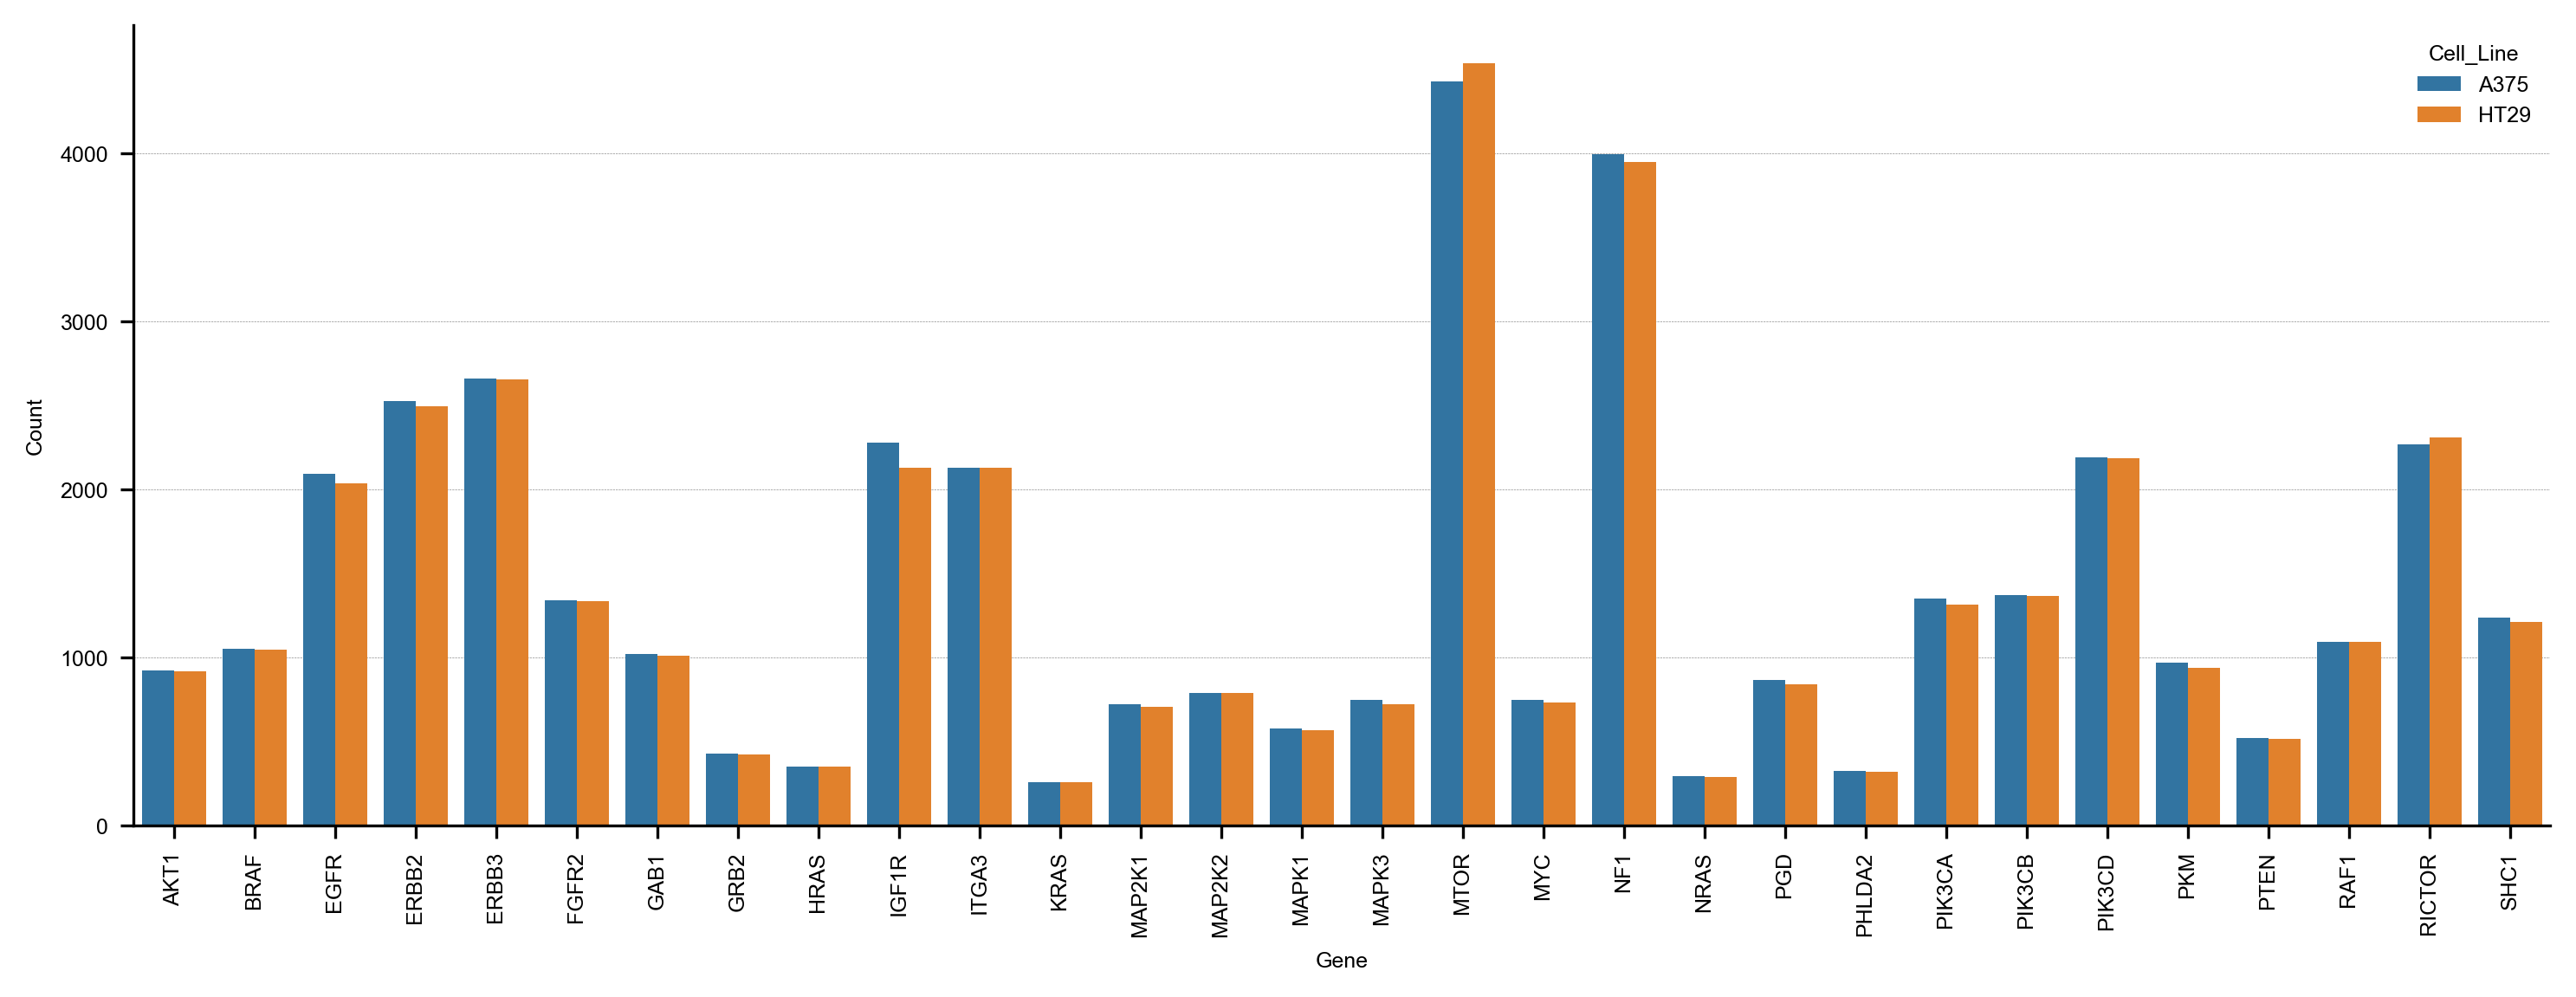

In [98]:
counts_before_DS = (
    annotated_control_EG
    .groupby(["Cell_Line", "Gene", "Class"])
    .size()
    .reset_index(name="Count")
)

counts_non_hits_before_DS = counts_before_DS[counts_before_DS["Class"] == "Neutral"]

plt.figure(figsize=(12,4))
sns.barplot(
    data=counts_non_hits_before_DS,
    x="Gene", y="Count", hue='Cell_Line', errorbar=None
)

plt.xticks(rotation=90)
plt.show()

In [99]:
def stratified_downsampling(df, random_state=None):
    """
    Perform stratified downsampling of 'non-hit' class to match the size of the 'negative' class,
    stratified by (Cell_Line × Gene).
    
    Parameters
    ----------
    df : pd.DataFrame
        Original dataset with 'Hit_class', 'Cell_Line', and 'Gene'.
    random_state : int, optional
        Random seed for reproducibility of subsampling.

    Returns
    -------
    df_balanced : pd.DataFrame
        Balanced dataset containing all negatives, all positives, and downsampled non-hits.
    """
    #Split dataset by class
    df_negative = df[df['Class'] == 'Sensitivity']
    df_non_hit = df[df['Class'] == 'Neutral']
    df_positive = df[df['Class'] == 'Resistance']

    #Target number of non-hit samples to match negative samples
    target_non_hit_count = len(df_positive)

    # Compute distribution of non-hits across Cell_Line × Gene
    non_hit_distribution = (
        df_non_hit
        .groupby(['Cell_Line', 'Gene'])
        .size()
        .reset_index(name='Count')
    )

    # Calculate proportions
    non_hit_distribution['Proportion'] = non_hit_distribution['Count'] / non_hit_distribution['Count'].sum()

    # Determine number of samples to select from each Cell_Line × Gene
    non_hit_distribution['Target'] = np.floor(non_hit_distribution['Proportion'] * target_non_hit_count).astype(int)

    # Adjust target to ensure total matches target_non_hit_count - distribute the remaining samples to the groups with the largest fractional remainders
    difference = target_non_hit_count - non_hit_distribution['Target'].sum()

    if difference > 0:
        fractional_parts = non_hit_distribution['Proportion'] * target_non_hit_count - non_hit_distribution['Target']
        top_idx = fractional_parts.nlargest(difference).index
        non_hit_distribution.loc[top_idx, 'Target'] += 1

    #Perform stratified downsampling
    downsampled_non_hits = []
    for _, row in non_hit_distribution.iterrows():
        cell_line = row['Cell_Line']
        gene = row['Gene']
        target = row['Target']
        
        subset = df_non_hit[(df_non_hit['Cell_Line'] == cell_line) & (df_non_hit['Gene'] == gene)]

        if target > 0:
            n_sampled = min(target, len(subset)) # in case very small group
            downsampled_non_hits.append(subset.sample(n=n_sampled, random_state=random_state))
        
    df_non_hit_downsampled = pd.concat(downsampled_non_hits, ignore_index=True)

    # Combine downsampled non-hits with other classes
    df_balanced = pd.concat([df_negative, df_non_hit_downsampled, df_positive], ignore_index=True)

    return df_balanced

In [68]:
annotated_plasmid_EG_balanced = stratified_downsampling(annotated_plasmid_EG, random_state=1)

In [100]:
#For control
annotated_control_EG_balanced = stratified_downsampling(annotated_control_EG, random_state=1)

In [47]:
print("Final class counts:")
print(annotated_control_EG_balanced["Class"].value_counts())

Final class counts:
Class
Neutral        788
Resistance     788
Sensitivity    451
Name: count, dtype: int64


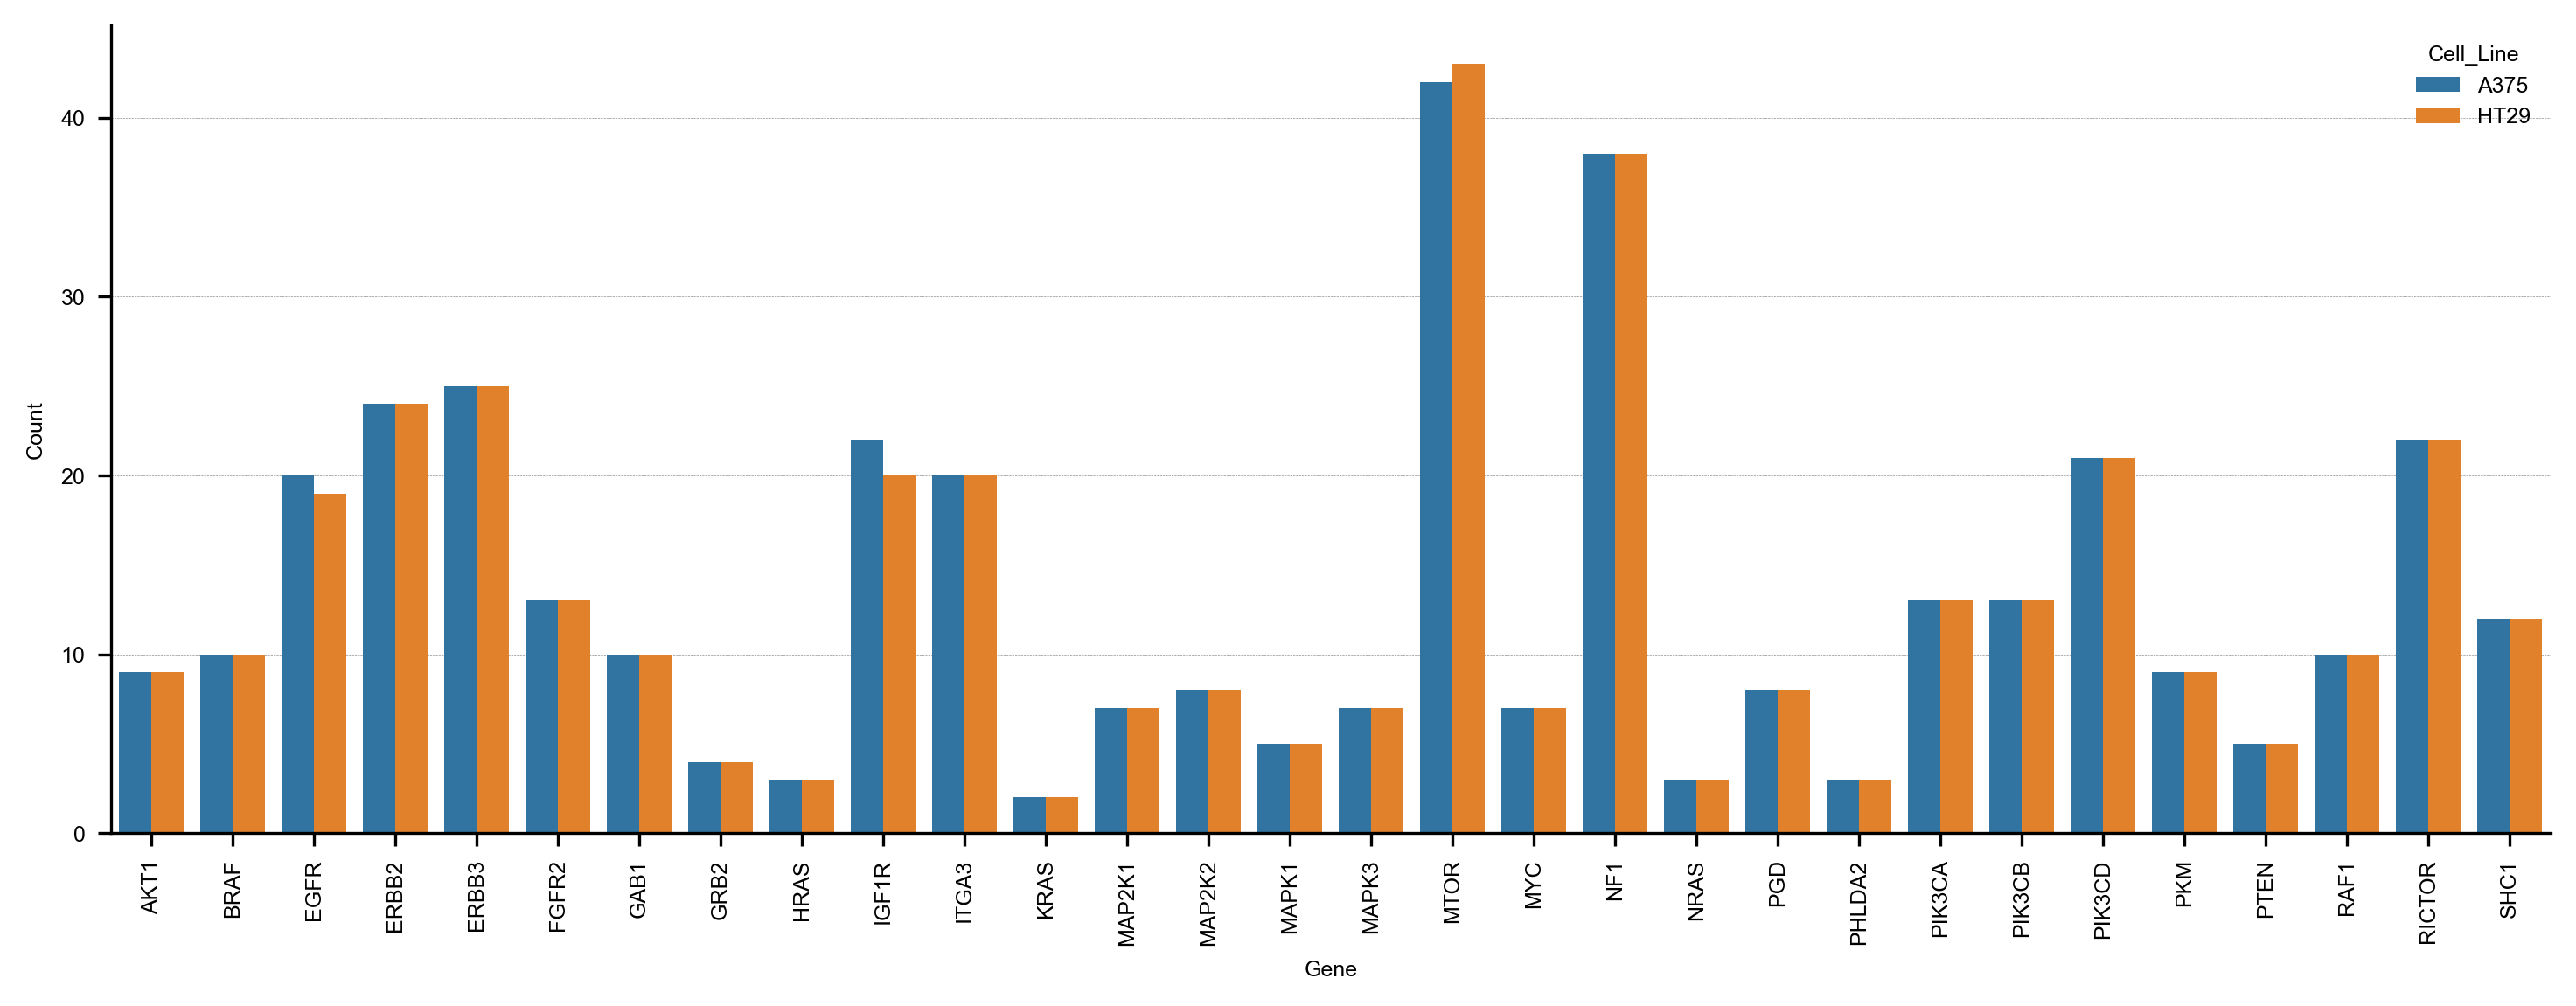

In [19]:
#Check distribution of non-hits after downsampling

counts_after_DS = (
    annotated_control_EG_balanced
    .groupby(["Cell_Line", "Gene", "Class"])
    .size()
    .reset_index(name="Count")
)

counts_non_hits_after_DS = counts_after_DS[counts_after_DS["Class"] == "Neutral"]

plt.figure(figsize=(12,4))
sns.barplot(
    data=counts_non_hits_after_DS,
    x="Gene", y="Count", hue="Cell_Line", errorbar=None
)

plt.xticks(rotation=90)
plt.show()

In [ ]:
#Create a df to compare the proportions of each class before and after downsampling
comparison_df = pd.DataFrame({
    'Before_Downsampling': annotated_plasmid_EG['Class'].value_counts().sort_index(),
    'After_Downsampling': annotated_plasmid_EG_balanced['Class'].value_counts().sort_index()
}).reset_index().rename(columns={'index': 'Class'})
comparison_df

In [18]:
#For control
comparison_control_df = pd.DataFrame({
    'Before_Downsampling': annotated_control_EG['Class'].value_counts().sort_index(),
    'After_Downsampling': annotated_control_EG_balanced['Class'].value_counts().sort_index()
}).reset_index().rename(columns={'index': 'Class'})
comparison_control_df

,Class,Before_Downsampling,After_Downsampling
0,Neutral,83019,788
1,Resistance,788,788
2,Sensitivity,451,451


In [ ]:
# Compute proportions within each group (Cell_Line × Gene)
prop_before = counts_non_hits_before_DS.copy()
prop_before["Proportion_before_DS"] = round(prop_before["Count"] / prop_before["Count"].sum(),4)
prop_before = prop_before[["Cell_Line", "Gene", "Proportion_before_DS"]]

prop_after = counts_non_hits_after_DS.copy()
prop_after["Proportion_after_DS"] = round(prop_after["Count"] / prop_after["Count"].sum(), 4)
prop_after = prop_after[["Cell_Line", "Gene", "Proportion_after_DS"]]


prop_compare = pd.merge(prop_before, prop_after,
                        on=["Cell_Line", "Gene"], how="inner")

# Correlation of proportions
corr = prop_compare["Proportion_before_DS"].corr(prop_compare["Proportion_after_DS"])

print("Correlation of per-group proportions (before vs after downsampling):", round(corr, 4))
print("\nProportion comparison (first 10 rows):")
print(prop_compare.head(10))

## Modeling

### Split into Features (X) and labels (y)

In [101]:
#Define meta data columns to drop + include the gene expression column I don't want to test (raw or voom)
meta_cols=[
    'Target Transcript ID', 'RefSeq match transcript (MANE Select)', 'Guide', 'Editor', 'Gene', 'Cell_Line','Drug', 'Amino Acid Edits', 
    'Class', 'zscore', 'Source', 'uniprot_accession', 'aa_change', 'pocket_id'#, 'wild_type', 'uniprot_position', 'mutated_type', 'Gene_expression_expected_counts'
]

#Split into features and labels
X = annotated_control_EG_balanced.drop(columns=meta_cols + ["Class_encoded"])
y = annotated_control_EG_balanced["Class_encoded"]

print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

Feature matrix shape: (2027, 52)
Label vector shape: (2027,)


In [102]:
X.head()

,Mutation_Category_enc,IMPACT_enc,TSL,SIFT_pathogenicity,PolyPhen_pathogenicity,REVEL,ClinPred,EVE_SCORE,AlphaMissense_score,BayesDel_noAF_score,DANN_score,DEOGEN2_score,ESM1b_score,Eigen-PC-phred_coding,Eigen-PC-raw_coding,GERP++_NR,GERP++_RS,LIST-S2_score,MPC_rankscore,MPC_score,MVP_score,MetaRNN_score,MetaSVM_score,MutFormer_score,MutationAssessor_score,PROVEAN_score,PrimateAI_pred_enc,VARITY_R_LOO_score,bStatistic,fathmm-XF_coding_score,gMVP_score,phastCons100way_vertebrate,phyloP100way_vertebrate,CADD_PHRED,MaxEntScan_alt,MaxEntScan_diff,MaxEntScan_ref,SpliceAI_pred_DP_AG,SpliceAI_pred_DP_AL,SpliceAI_pred_DP_DG,SpliceAI_pred_DP_DL,SpliceAI_pred_DS_AG,SpliceAI_pred_DS_AL,SpliceAI_pred_DS_DG,SpliceAI_pred_DS_DL,BLOSUM62,LOEUF,mutfunc_exp,ada_score,Gene_expression_voom,foldx_ddg,min_pocket_buriedness
0,2.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.594,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.703,NaN,NaN,8.443585,NaN,NaN
1,3.0,2.0,1.0,0.0,NaN,0.876,0.999938,0.983177,0.9997,0.376218,0.998253,0.901346,-14.646,16.6271,0.960830,5.51,5.51,0.963704,0.99644,3.350520,0.949545,0.947140,0.8686,0.996138,4.49,-9.76,0.0,0.992620,403.0,0.892481,0.998039,1.0,7.248,27.800,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-2.0,0.268,NaN,NaN,7.055406,9.038830,NaN
2,3.0,2.0,1.0,0.0,0.995,0.430,0.944457,0.806266,0.9638,0.006105,0.999447,0.782876,-7.062,11.7622,0.849728,5.70,5.70,0.909909,0.88192,1.573937,0.683547,0.892936,-0.2861,0.082219,3.48,-3.64,0.0,0.899651,291.0,0.857350,0.640744,1.0,7.478,25.800,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.268,NaN,NaN,7.055406,-0.125354,NaN
3,2.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.268,0.0,NaN,7.055406,NaN,NaN
4,5.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31.000,5.162,8.75,13.913,-1.0,1.0,34.0,18.0,0.02,1.0,0.0,0.0,NaN,0.330,NaN,0.999986,7.649702,NaN,NaN


In [103]:
y.head()

0    2
1    2
2    2
3    2
4    2
Name: Class_encoded, dtype: int64

### Model 

In [55]:
#first with no hyperparameter tuning
xgb_classifier = XGBClassifier(random_state=1)


#Model with optimized hyperparameters 
xgb_classifier_optimized = XGBClassifier(
    subsample=0.85,
    reg_lambda=1.3,
    reg_alpha=1,
    n_estimators=300,
    min_child_weight=3,
    max_depth=9,
    learning_rate=0.2,
    colsample_bytree=1.0,
    objective="multi:softprob",   
    num_class=len(le.classes_),   
    random_state=1,
    n_jobs=-1                    
)

#Model with optimized hyperparameters in the drug vs DMSO gene expression dataset
xgb_classifier_optimized_drugvsDMSO_geneExpress = XGBClassifier(
    subsample=0.7,
    reg_lambda=1,
    reg_alpha=0.1,
    n_estimators=300,
    min_child_weight=1,
    max_depth=12,
    learning_rate=0.01,
    colsample_bytree=0.7,
    objective="multi:softprob",   
    num_class=len(le.classes_),   
    random_state=1,
    n_jobs=-1                    
)
#Stratified 5-fold cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

#colect predictions and true labels for each fold + metrics
fold_classif_reports = []
roc_auc_scores_weighted = []
roc_auc_scores_macro = []
pr_auc_scores_weighted = []
pr_auc_scores_macro = []
all_y_true = []
all_y_pred = []
all_probs = []


for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    xgb_classifier_optimized_drugvsDMSO_geneExpress.fit(X_train, y_train)
    y_pred = xgb_classifier_optimized_drugvsDMSO_geneExpress.predict(X_val)
    probs = xgb_classifier_optimized_drugvsDMSO_geneExpress.predict_proba(X_val) 

    #ROC AUC
    roc_auc_weighted = roc_auc_score(y_val, probs, multi_class="ovr", average='weighted')
    roc_auc_macro = roc_auc_score(y_val, probs, multi_class="ovr", average='macro')
    roc_auc_scores_weighted.append(roc_auc_weighted)
    roc_auc_scores_macro.append(roc_auc_macro)

    #PR AUC
    pr_auc_weighted = average_precision_score(y_val, probs, average='weighted')
    pr_auc_macro = average_precision_score(y_val, probs, average='macro')

    pr_auc_scores_weighted.append(pr_auc_weighted)
    pr_auc_scores_macro.append(pr_auc_macro)


    all_y_true.extend(y_val)
    all_y_pred.extend(y_pred)
    all_probs.append(probs)

    report = classification_report(y_val, y_pred, target_names=le.classes_, output_dict=True)
    fold_classif_reports.append(report)

    print(f"\n=== Fold {fold+1} ===")
    print(classification_report(y_val, y_pred, target_names=le.classes_, digits=3))
    print(f"ROC AUC (weighted): {roc_auc_weighted:.3f}")
    print(f"PR AUC (weighted): {pr_auc_weighted:.3f}")

all_probs = np.concatenate(all_probs, axis=0)


=== Fold 1 ===
              precision    recall  f1-score   support

     Neutral      0.635     0.764     0.694       157
  Resistance      0.713     0.614     0.660       158
 Sensitivity      0.667     0.593     0.628        91

    accuracy                          0.667       406
   macro avg      0.672     0.657     0.660       406
weighted avg      0.673     0.667     0.666       406

ROC AUC (weighted): 0.795
PR AUC (weighted): 0.682

=== Fold 2 ===
              precision    recall  f1-score   support

     Neutral      0.663     0.709     0.685       158
  Resistance      0.697     0.684     0.690       158
 Sensitivity      0.659     0.600     0.628        90

    accuracy                          0.675       406
   macro avg      0.673     0.664     0.668       406
weighted avg      0.675     0.675     0.674       406

ROC AUC (weighted): 0.819
PR AUC (weighted): 0.728

=== Fold 3 ===
              precision    recall  f1-score   support

     Neutral      0.667     0.722

In [56]:
# === Average metrics ===
avg_report = {}
avg_report["accuracy"] = np.mean([r["accuracy"] for r in fold_classif_reports])
avg_report["macro avg"] = {
    metric: np.mean([r["macro avg"][metric] for r in fold_classif_reports])
    for metric in ["precision", "recall", "f1-score"]
}
avg_report["weighted avg"] = {
    metric: np.mean([r["weighted avg"][metric] for r in fold_classif_reports])
    for metric in ["precision", "recall", "f1-score"]
}

avg_report["Resistance"] = {
    metric: np.mean([r["Resistance"][metric] for r in fold_classif_reports])
    for metric in ["precision", "recall", "f1-score"]
}
avg_report["Sensitivity"] = {
    metric: np.mean([r["Sensitivity"][metric] for r in fold_classif_reports])
    for metric in ["precision", "recall", "f1-score"]
}
avg_report["Neutral"] = {
    metric: np.mean([r["Neutral"][metric] for r in fold_classif_reports])
    for metric in ["precision", "recall", "f1-score"]
}

avg_roc_auc_weighthed = np.mean(roc_auc_scores_weighted)
avg_roc_auc_macro = np.mean(roc_auc_scores_macro)

avg_pr_auc_weighthed = np.mean(pr_auc_scores_weighted)
avg_pr_auc_macro = np.mean(pr_auc_scores_macro)

def round_dict(d, ndigits=3):
    return {k: round(float(v), ndigits) for k, v in d.items()}

print("\n=== Average CV Results ===")
print("Accuracy:", round(float(avg_report["accuracy"]), 3))
print("ROC AUC (weighted):", round(float(avg_roc_auc_weighthed), 3))
print("ROC AUC (macro):", round(float(avg_roc_auc_macro), 3))
print("PR AUC (weighted):", round(float(avg_pr_auc_weighthed), 3))
print("PR AUC (macro):", round(float(avg_pr_auc_macro), 3))
print("\nClass-wise metrics:")
print("Resistance:", round_dict(avg_report["Resistance"]))
print("Sensitivity:", round_dict(avg_report["Sensitivity"]))
print("Neutral:", round_dict(avg_report["Neutral"]))
print("\nMacro Avg:", round_dict(avg_report["macro avg"]))
print("Weighted Avg:", round_dict(avg_report["weighted avg"]))



=== Average CV Results ===
Accuracy: 0.672
ROC AUC (weighted): 0.81
ROC AUC (macro): 0.812
PR AUC (weighted): 0.709
PR AUC (macro): 0.702

Class-wise metrics:
Resistance: {'precision': 0.716, 'recall': 0.649, 'f1-score': 0.68}
Sensitivity: {'precision': 0.68, 'recall': 0.59, 'f1-score': 0.631}
Neutral: {'precision': 0.638, 'recall': 0.744, 'f1-score': 0.686}

Macro Avg: {'precision': 0.678, 'recall': 0.661, 'f1-score': 0.666}
Weighted Avg: {'precision': 0.678, 'recall': 0.672, 'f1-score': 0.671}


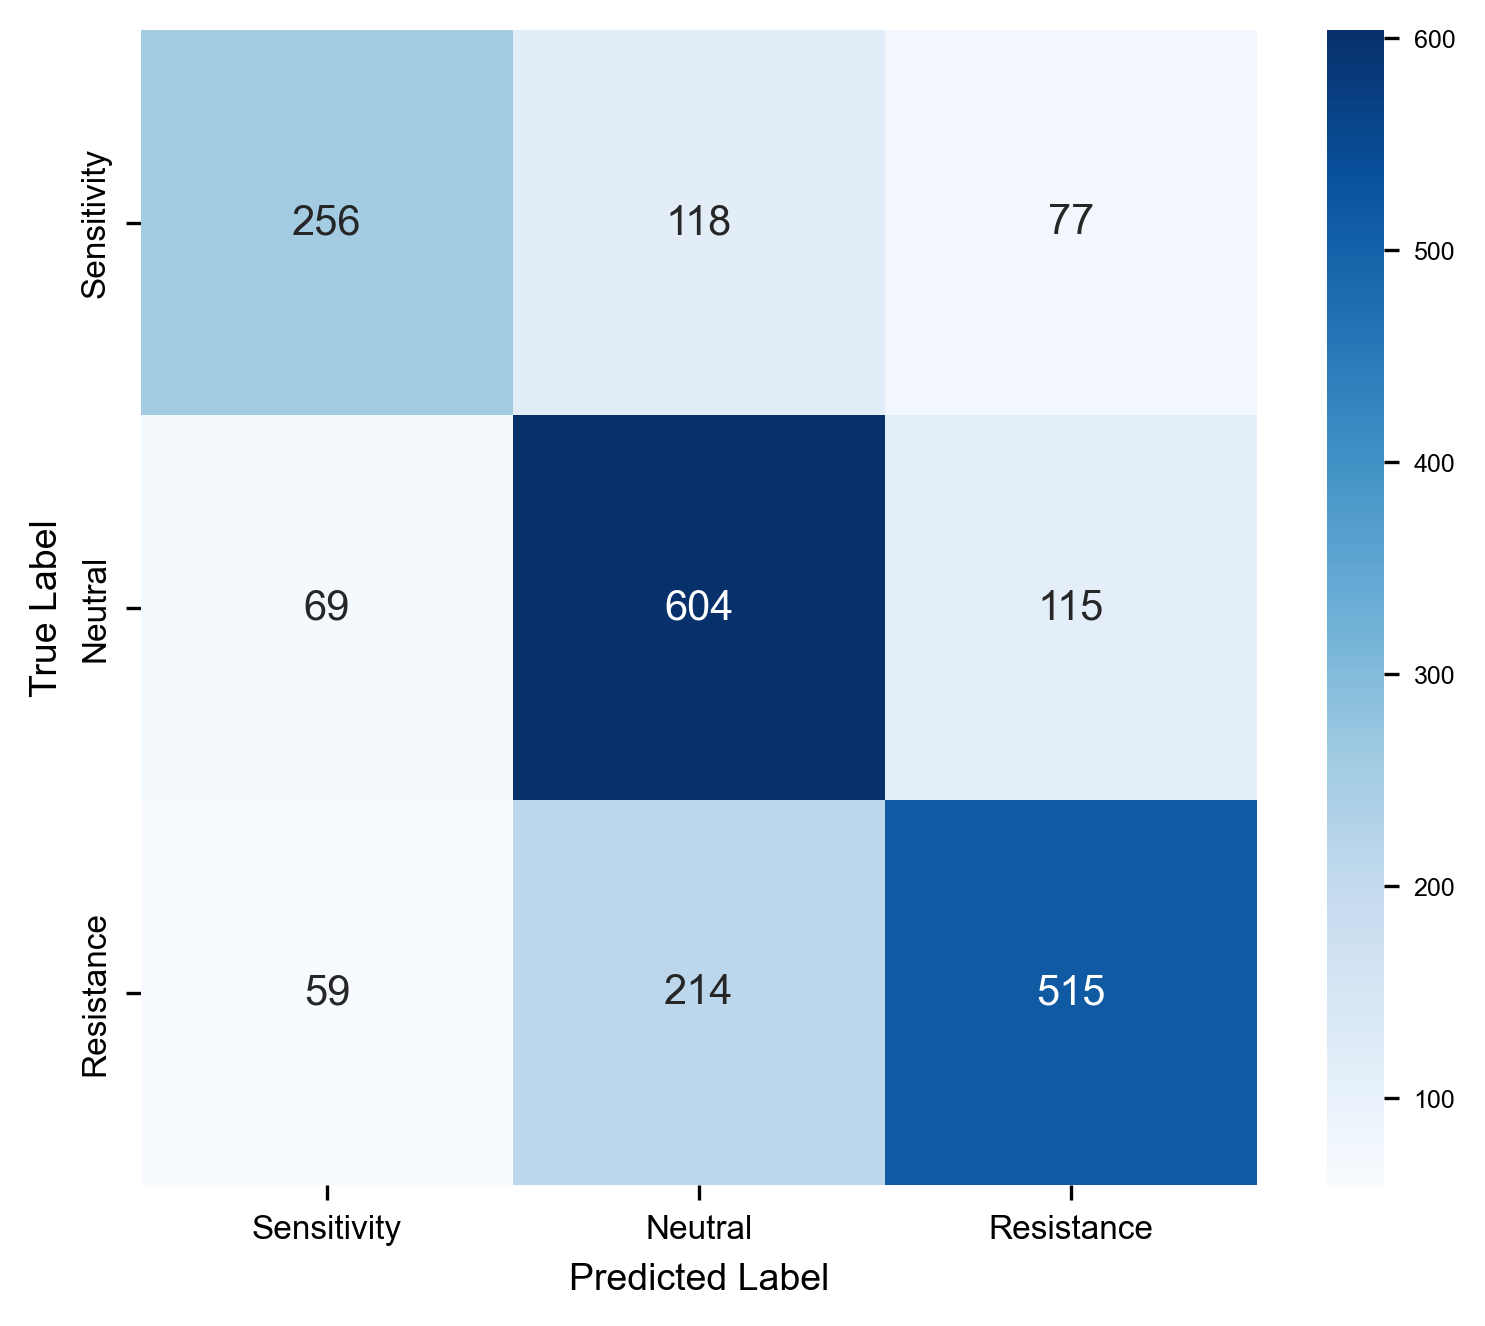

In [33]:
# Single-run confusion matrix plot

ordered_labels = ['Sensitivity', 'Neutral', 'Resistance']

cm = confusion_matrix(all_y_true, all_y_pred, labels=le.transform(ordered_labels))

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=ordered_labels, yticklabels=ordered_labels)
plt.yticks(fontsize=8)
plt.xticks(fontsize=8)
plt.xlabel("Predicted Label", fontsize=9)
plt.ylabel("True Label", fontsize=9)
plt.show()

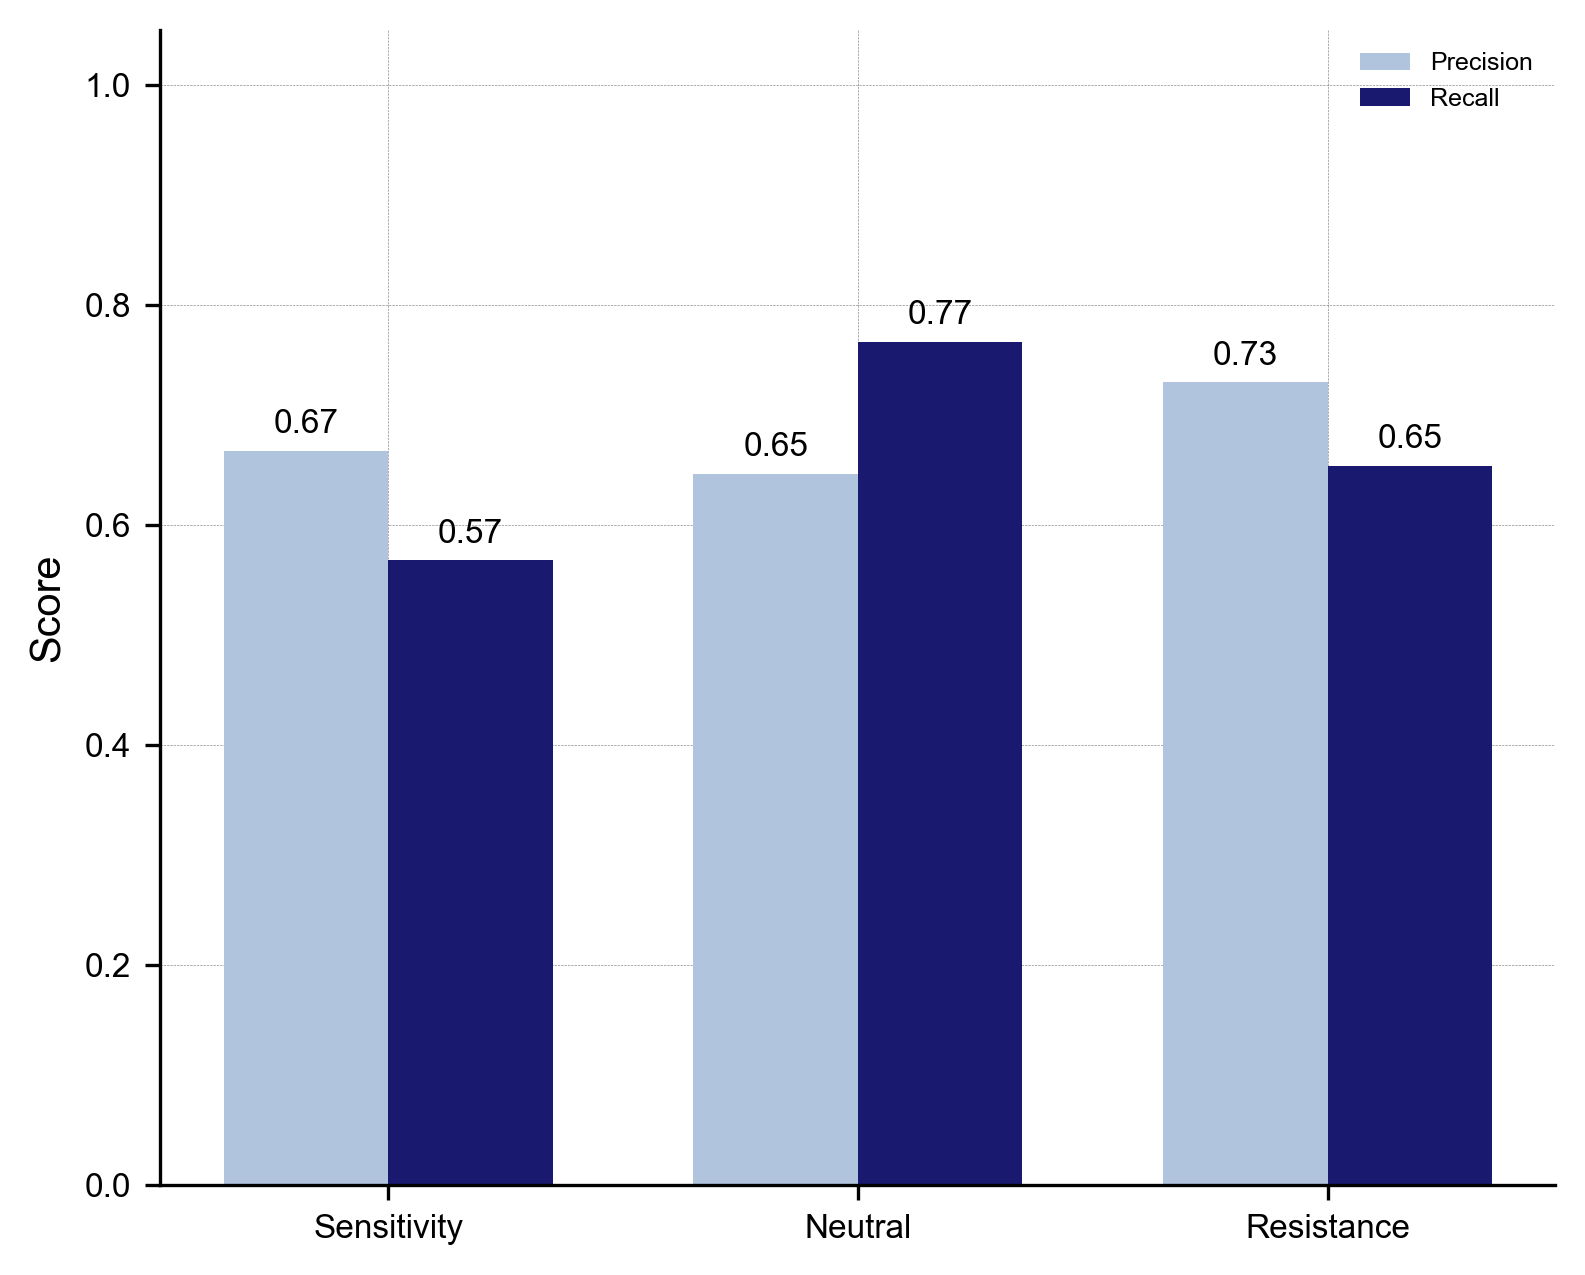

In [34]:
# Extract precision and recall per class from avg_report
class_names = ["Sensitivity", "Neutral", "Resistance"]

precision_means = [avg_report[c]["precision"] for c in class_names]
recall_means    = [avg_report[c]["recall"] for c in class_names]

x = np.arange(len(class_names))  # positions
width = 0.35  # bar width

plt.figure(figsize=(6,5))
bars1 = plt.bar(x - width/2, precision_means, width, label="Precision", color="lightsteelblue")
bars2 = plt.bar(x + width/2, recall_means, width, label="Recall", color="midnightblue")

# Add numbers on top of bars
for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.01, 
             f"{height:.2f}", ha='center', va='bottom', fontsize=8)

for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.01, 
             f"{height:.2f}", ha='center', va='bottom', fontsize=8)

# Customize fonts
plt.xticks(x, class_names, fontsize=8)
plt.yticks(fontsize=8)
plt.ylabel("Score", fontsize=10)
#plt.title("Precision and Recall per Class (5-fold CV average)", fontsize=16)
plt.legend(loc="upper right", fontsize=6)

plt.ylim(0, 1.05)  # leave space for labels
plt.show()

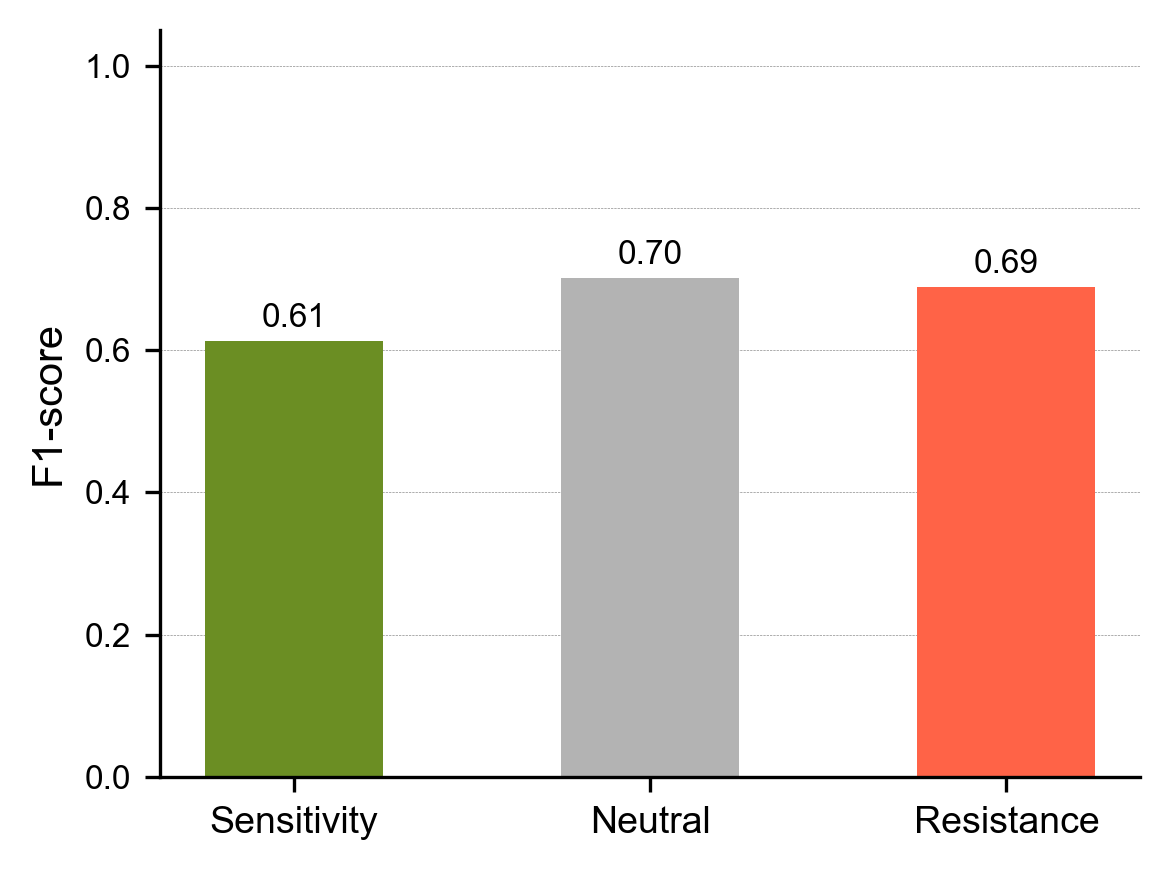

In [74]:
# Extract mean F1-scores from avg_report
class_names = ["Sensitivity", "Neutral", "Resistance"]
f1_means = [avg_report[c]["f1-score"] for c in class_names]

x = np.arange(len(class_names))
width = 0.5  # single bar width
colors_bar = ["olivedrab", "#b3b3b3","tomato"]
plt.figure(figsize=(4, 3))
bars = plt.bar(x, f1_means, width, color=colors_bar)

# Add text labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.01,
             f"{height:.2f}", ha='center', va='bottom', fontsize=8)

# Labels and style
plt.xticks(x, class_names, fontsize=9)
plt.ylabel("F1-score", fontsize=10)
plt.yticks(fontsize=8)
#plt.title("Mean F1-score per Class (5-fold CV average)", fontsize=12)
plt.ylim(0, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.grid(False, axis='x')
plt.tight_layout()
plt.show()

LabelEncoder class order: ['Neutral' 'Resistance' 'Sensitivity']
This is the order of columns in predict_proba(X) ↑


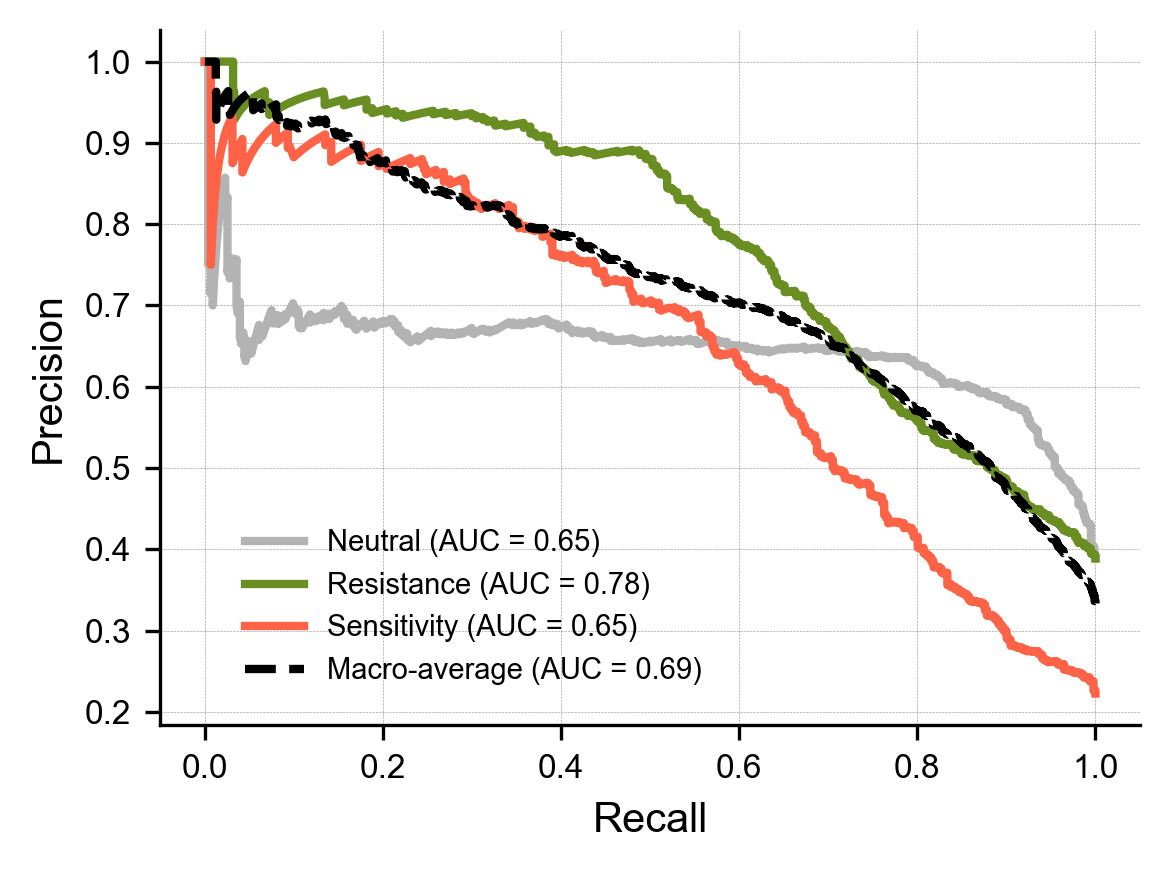

In [67]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import numpy as np

# Verify label order
print("LabelEncoder class order:", le.classes_)
print("This is the order of columns in predict_proba(X) ↑")

# Binarize using integer indices [0, 1, 2, ...] corresponding to le.classes_
classes_for_binarize = np.arange(len(le.classes_))
y_true_bin = label_binarize(all_y_true, classes=classes_for_binarize)
n_classes = y_true_bin.shape[1]

# Optional: teal-based color palette for consistency
colors = ["#b3b3b3", "olivedrab", "tomato"]

plt.figure(figsize=(4, 3))

# Loop through classes and plot
for i, class_name in enumerate(le.classes_):
    precision, recall, _ = precision_recall_curve(y_true_bin[:, i], all_probs[:, i])
    pr_auc = average_precision_score(y_true_bin[:, i], all_probs[:, i])
    plt.plot(recall, precision, lw=2, color=colors[i],
             label=f"{class_name} (AUC = {pr_auc:.2f})")

# Optional macro-average curve
precision_macro, recall_macro, _ = precision_recall_curve(y_true_bin.ravel(), all_probs.ravel())
pr_auc_macro = average_precision_score(y_true_bin, all_probs, average="macro")
plt.plot(recall_macro, precision_macro, color="black", lw=2, linestyle="--",
         label=f"Macro-average (AUC = {pr_auc_macro:.2f})")

# Labels and styling
plt.xlabel("Recall", fontsize=10)
plt.ylabel("Precision", fontsize=10)
plt.yticks(fontsize=8)
plt.xticks(fontsize=8)

#
# plt.title("Precision–Recall Curves per Class (All CV Folds Combined)", fontsize=12)
plt.legend(fontsize=7, loc="lower left", frameon=False, bbox_to_anchor=(0.06, 0.02))
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

### Run 10 times

In [112]:
def train_test_once(df, model, meta_cols, le, cv, stratified_downsampling, random_state_for_downsampling):

    #Perform stratified downsampling
    df_balanced = stratified_downsampling(df, random_state=random_state_for_downsampling)

    #Separate train and test sets
    X = df_balanced.drop(columns=meta_cols + ["Class_encoded"])
    y = df_balanced["Class_encoded"]

    class_names = list(le.classes_)
    n_classes = len(class_names)

    fold_reports = []
    roc_auc_scores_weighted, roc_auc_scores_macro = [], []
    pr_auc_scores_weighted, pr_auc_scores_macro = [], []
    all_y_true, all_y_pred, all_probs = [], [], []
    shap_values_folds = []
    X_val_folds = []

    for fold, (train_idx, val_idx) in enumerate(cv.split(X, y)):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)
        probs = model.predict_proba(X_val) 

        #SHAP 
        explainer = shap.TreeExplainer(model)
        shap_vals = explainer.shap_values(X_val)


        #Store predictions, true labels and probabilities 
        all_y_true.extend(y_val)
        all_y_pred.extend(y_pred)
        all_probs.extend(probs)

        #SHAP
        shap_values_folds.append(shap_vals)
        X_val_folds.append(X_val)

        #ROC AUC
        roc_auc_scores_weighted.append(roc_auc_score(y_val, probs, multi_class="ovr", average='weighted'))
        roc_auc_scores_macro.append(roc_auc_score(y_val, probs, multi_class="ovr", average='macro'))

        #PR AUC
        pr_auc_scores_weighted.append(average_precision_score(y_val, probs, average='weighted'))
        pr_auc_scores_macro.append(average_precision_score(y_val, probs, average='macro'))

        fold_reports.append(classification_report(y_val, y_pred, target_names=le.classes_, output_dict=True))


    # Aggregate metrics - average across folds 
    metrics = {}
    metrics["accuracy"] = np.mean([r["accuracy"] for r in fold_reports])

    for avg_key in ["macro avg", "weighted avg"]:
        metrics[f"precision_{avg_key}"] = np.mean([r[avg_key]["precision"] for r in fold_reports])
        metrics[f"recall_{avg_key}"] = np.mean([r[avg_key]["recall"] for r in fold_reports])
        metrics[f"f1_{avg_key}"] = np.mean([r[avg_key]["f1-score"] for r in fold_reports])

    for cname in class_names:
        metrics[f"precision_{cname}"] = np.mean([r[cname]["precision"] for r in fold_reports])
        metrics[f"recall_{cname}"] = np.mean([r[cname]["recall"]    for r in fold_reports])
        metrics[f"f1_{cname}"] = np.mean([r[cname]["f1-score"]  for r in fold_reports])

    metrics["roc_auc_weighted"] = np.mean(roc_auc_scores_weighted)
    metrics["roc_auc_macro"] = np.mean(roc_auc_scores_macro)
    metrics["pr_auc_weighted"] = np.mean(pr_auc_scores_weighted)
    metrics["pr_auc_macro"] = np.mean(pr_auc_scores_macro)

    cm = confusion_matrix(all_y_true, all_y_pred, labels=np.arange(len(le.classes_)))
    return metrics, cm, np.array(all_y_true), np.array(all_probs), shap_values_folds, X_val_folds

In [113]:
# Run multiple times to get average performance across different downsamplings
n_runs = 10
all_metrics, all_cms = [], []
all_y_true_runs, all_probs_runs = [], []
all_shap_values_runs, all_X_val_runs = [], []

xgb_classifier_optimized = XGBClassifier(
    subsample=0.85,
    reg_lambda=0.5,
    reg_alpha=1,
    n_estimators=700,
    min_child_weight=1,
    max_depth=9,
    learning_rate=0.01,
    colsample_bytree=0.85,
    objective="multi:softprob",   
    num_class=len(le.classes_),   
    random_state=1,
    n_jobs=-1                    
)
#Model with optimized hyperparameters in the drug vs DMSO gene expression dataset
xgb_classifier_optimized_drugvsDMSO_geneExpress = XGBClassifier(
    subsample=0.7,
    reg_lambda=1,
    reg_alpha=0.1,
    n_estimators=300,
    min_child_weight=1,
    max_depth=12,
    learning_rate=0.01,
    colsample_bytree=0.7,
    objective="multi:softprob",   
    num_class=len(le.classes_),   
    random_state=1,
    n_jobs=-1                    
)

#Stratified 5-fold cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

for i in range(n_runs):
    print(f"\n--- Run {i+1}/{n_runs} ---")
    metrics, cm, y_true, probs, shap_values_folds, X_val_folds = train_test_once(
        df=annotated_control_EG,
        model=xgb_classifier_optimized_drugvsDMSO_geneExpress,
        meta_cols=meta_cols,
        le=le,
        cv=skf,
        stratified_downsampling=stratified_downsampling,
        random_state_for_downsampling=i
    )
    all_metrics.append(metrics)
    all_cms.append(cm)
    all_y_true_runs.append(y_true)
    all_probs_runs.append(probs)
    print("Metrics:", metrics)
    print("Confusion Matrix:\n", cm)

    #SHAP
    #.extend because i don't need run level separation here
    all_shap_values_runs.extend(shap_values_folds)
    all_X_val_runs.extend(X_val_folds)

# === Aggregate metrics across runs ===
metrics_df = pd.DataFrame(all_metrics)
metrics_mean = metrics_df.mean()
metrics_std = metrics_df.std()

cm_mean = np.mean(np.array(all_cms, dtype=float), axis=0)
cm_std  = np.std(np.array(all_cms, dtype=float), axis=0)

# Reorder confusion matrix
desired_order = ["Sensitivity", "Neutral", "Resistance"]

# Map to label encoder indices
reorder_idx = [list(le.classes_).index(c) for c in desired_order]

# Reorder rows and columns
cm_mean = cm_mean[np.ix_(reorder_idx, reorder_idx)]
cm_std  = cm_std[np.ix_(reorder_idx, reorder_idx)]

# Update class_names for correct axis labels
class_names_reordered = desired_order

print("=== Mean metrics ===")
print(metrics_mean)
print("\n=== Std metrics ===")
print(metrics_std)

print("\n=== Mean confusion matrix ===")
print(cm_mean)
print("\n=== Std confusion matrix ===")
print(cm_std)


--- Run 1/10 ---
Metrics: {'accuracy': np.float64(0.6664988140850211), 'precision_macro avg': np.float64(0.6722422517649658), 'recall_macro avg': np.float64(0.650863253999592), 'f1_macro avg': np.float64(0.6570171147422496), 'precision_weighted avg': np.float64(0.6718074340279242), 'recall_weighted avg': np.float64(0.6664988140850211), 'f1_weighted avg': np.float64(0.6648584552214193), 'precision_Neutral': np.float64(0.6273610818360225), 'recall_Neutral': np.float64(0.7411674594856082), 'f1_Neutral': np.float64(0.6788644563968191), 'precision_Resistance': np.float64(0.7144854637968102), 'recall_Resistance': np.float64(0.6548899459808111), 'f1_Resistance': np.float64(0.6824457999307134), 'precision_Sensitivity': np.float64(0.6748802096620645), 'recall_Sensitivity': np.float64(0.5565323565323566), 'f1_Sensitivity': np.float64(0.6097410878992159), 'roc_auc_weighted': np.float64(0.7979572909020491), 'roc_auc_macro': np.float64(0.8017883790535982), 'pr_auc_weighted': np.float64(0.685155029

#### Get metrics

In [34]:
def summarize_results(metrics_list, cms, class_names):
    """
    Summarize metrics (global + class-wise) and confusion matrices across runs.

    Parameters
    ----------
    metrics_list : list of dict
        Each element is the metrics dict returned from train_test_once.
    cms : list of np.ndarray
        Confusion matrices (one per run).
    class_names : list
        Names of classes for the confusion matrix.
    """

    # === Metrics summary ===
    metrics_keys = metrics_list[0].keys()
    summary = {}
    for key in metrics_keys:
        values = np.array([m[key] for m in metrics_list])
        summary[key] = (np.mean(values), np.std(values))

    print("\n=== Metrics Summary (mean ± std) ===")

    # Global averages
    for k in ["accuracy", "roc_auc_weighted", "roc_auc_macro",
              "pr_auc_weighted", "pr_auc_macro"]:
        mean, std = summary[k]
        print(f"{k:20s}: {mean:.3f} ± {std:.3f}")

    # Macro/weighted averages
    for k in ["precision_macro avg", "recall_macro avg", "f1_macro avg",
              "precision_weighted avg", "recall_weighted avg", "f1_weighted avg"]:
        if k in summary:
            mean, std = summary[k]
            print(f"{k:20s}: {mean:.3f} ± {std:.3f}")

    # Class-wise metrics
    print("\n=== Class-wise Metrics (mean ± std) ===")
    for cname in class_names:
        for metric in ["precision", "recall", "f1"]:
            key = f"{metric}_{cname}"
            if key in summary:
                mean, std = summary[key]
                print(f"{cname:10s} {metric:10s}: {mean:.3f} ± {std:.3f}")

   # === Confusion Matrix summary ===
    cm_array = np.stack(cms)  # shape (n_runs, n_classes, n_classes)
    cm_mean = np.mean(cm_array, axis=0)
    cm_std = np.std(cm_array, axis=0)

    # Combined annotated version
    combined = np.empty(cm_mean.shape, dtype=object)
    for i in range(cm_mean.shape[0]):
        for j in range(cm_mean.shape[1]):
            mean_val = int(round(cm_mean[i, j]))   # integer
            std_val = int(cm_std[i, j])       # 1 decimal
            combined[i, j] = f"{mean_val}±{std_val}"

    #for i in range(cm_mean.shape[0]):
    #    for j in range(cm_mean.shape[1]):
    #        combined[i, j] = f"{cm_mean[i,j]:.1f}±{cm_std[i,j]:.1f}"

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm_mean, annot=combined, fmt="", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, annot_kws={"size": 8})
    #plt.title("Confusion Matrix (mean ± std)")
    plt.yticks(fontsize=8)
    plt.xticks(fontsize=8)
    plt.xlabel("Predicted Label", fontsize=9)
    plt.ylabel("True Label", fontsize=9)
    plt.show()

# === Bar plot: Precision & Recall per class (mean ± std) ===
    precision_means = [summary[f"precision_{c}"][0] for c in class_names]
    precision_stds  = [summary[f"precision_{c}"][1] for c in class_names]
    recall_means    = [summary[f"recall_{c}"][0] for c in class_names]
    recall_stds     = [summary[f"recall_{c}"][1] for c in class_names]

    x = np.arange(len(class_names))
    width = 0.35

    plt.figure(figsize=(6, 5))
    bars1 = plt.bar(x - width/2, precision_means, width,
                    yerr=precision_stds, capsize=3,
                    label="Precision", color="lightsteelblue")
    bars2 = plt.bar(x + width/2, recall_means, width,
                    yerr=recall_stds, capsize=3,
                    label="Recall", color="midnightblue")

    # Add numbers on top
    for bar in bars1:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.03,
                 f"{height:.2f}", ha='center', va='bottom', fontsize=8)
    for bar in bars2:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.03,
                 f"{height:.2f}", ha='center', va='bottom', fontsize=8)

    plt.xticks(x, class_names, fontsize=8)
    plt.ylabel("Score", fontsize=10)
    plt.ylim(0, 1.05)
    plt.legend(loc="upper right", fontsize=6)
    #plt.title("Precision and Recall per Class (mean ± std across runs)", fontsize=12)
    plt.show()

    return summary, cm_mean, cm_std

In [106]:
## TRY TO REORDER CM
def summarize_results(metrics_list, cms, class_names):
    """
    Summarize metrics (global + class-wise) and confusion matrices across runs.

    Parameters
    ----------
    metrics_list : list of dict
        Each element is the metrics dict returned from train_test_once.
    cms : list of np.ndarray
        Confusion matrices (one per run).
    class_names : list
        Names of classes for the confusion matrix.
    """

    # === Metrics summary ===
    metrics_keys = metrics_list[0].keys()
    summary = {}
    for key in metrics_keys:
        values = np.array([m[key] for m in metrics_list])
        summary[key] = (np.mean(values), np.std(values))

    print("\n=== Metrics Summary (mean ± std) ===")

    # Global averages
    for k in ["accuracy", "roc_auc_weighted", "roc_auc_macro",
              "pr_auc_weighted", "pr_auc_macro"]:
        mean, std = summary[k]
        print(f"{k:20s}: {mean:.3f} ± {std:.3f}")

    # Macro/weighted averages
    for k in ["precision_macro avg", "recall_macro avg", "f1_macro avg",
              "precision_weighted avg", "recall_weighted avg", "f1_weighted avg"]:
        if k in summary:
            mean, std = summary[k]
            print(f"{k:20s}: {mean:.3f} ± {std:.3f}")

    # Class-wise metrics
    print("\n=== Class-wise Metrics (mean ± std) ===")
    for cname in class_names:
        for metric in ["precision", "recall", "f1"]:
            key = f"{metric}_{cname}"
            if key in summary:
                mean, std = summary[key]
                print(f"{cname:10s} {metric:10s}: {mean:.3f} ± {std:.3f}")

   # === Confusion Matrix summary ===
    cm_array = np.stack(cms)
    cm_mean = np.mean(cm_array, axis=0)
    cm_std = np.std(cm_array, axis=0)

    # === Reorder ===
    desired_order = ["Sensitivity", "Neutral", "Resistance"]
    reorder_idx = [list(class_names).index(c) for c in desired_order]

    cm_mean = cm_mean[np.ix_(reorder_idx, reorder_idx)]
    cm_std  = cm_std[np.ix_(reorder_idx, reorder_idx)]

    class_names = desired_order

    # Combined annotated version
    combined = np.empty(cm_mean.shape, dtype=object)
    for i in range(cm_mean.shape[0]):
        for j in range(cm_mean.shape[1]):
            mean_val = int(round(cm_mean[i, j]))   
            std_val = int(cm_std[i, j])       
            combined[i, j] = f"{mean_val}±{std_val}"

    #for i in range(cm_mean.shape[0]):
    #    for j in range(cm_mean.shape[1]):
    #        combined[i, j] = f"{cm_mean[i,j]:.1f}±{cm_std[i,j]:.1f}"

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm_mean, annot=combined, fmt="", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, annot_kws={"size": 8})
    #plt.title("Confusion Matrix (mean ± std)")
    plt.yticks(fontsize=8)
    plt.xticks(fontsize=8)
    plt.xlabel("Predicted Label", fontsize=9)
    plt.ylabel("True Label", fontsize=9)
    plt.show()

# === Bar plot: Precision & Recall per class (mean ± std) ===
    precision_means = [summary[f"precision_{c}"][0] for c in class_names]
    precision_stds  = [summary[f"precision_{c}"][1] for c in class_names]
    recall_means    = [summary[f"recall_{c}"][0] for c in class_names]
    recall_stds     = [summary[f"recall_{c}"][1] for c in class_names]

    x = np.arange(len(class_names))
    width = 0.35

    plt.figure(figsize=(6, 5))
    bars1 = plt.bar(x - width/2, precision_means, width,
                    yerr=precision_stds, capsize=3,
                    label="Precision", color="lightsteelblue")
    bars2 = plt.bar(x + width/2, recall_means, width,
                    yerr=recall_stds, capsize=3,
                    label="Recall", color="midnightblue")

    # Add numbers on top
    for bar in bars1:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.03,
                 f"{height:.2f}", ha='center', va='bottom', fontsize=8)
    for bar in bars2:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.03,
                 f"{height:.2f}", ha='center', va='bottom', fontsize=8)

    plt.xticks(x, class_names, fontsize=8)
    plt.ylabel("Score", fontsize=10)
    plt.ylim(0, 1.05)
    plt.legend(loc="upper right", fontsize=6)
    #plt.title("Precision and Recall per Class (mean ± std across runs)", fontsize=12)
    plt.show()

    return summary, cm_mean, cm_std



=== Metrics Summary (mean ± std) ===
accuracy            : 0.669 ± 0.004
roc_auc_weighted    : 0.806 ± 0.004
roc_auc_macro       : 0.809 ± 0.004
pr_auc_weighted     : 0.702 ± 0.007
pr_auc_macro        : 0.695 ± 0.006
precision_macro avg : 0.673 ± 0.005
recall_macro avg    : 0.654 ± 0.004
f1_macro avg        : 0.659 ± 0.004
precision_weighted avg: 0.675 ± 0.004
recall_weighted avg : 0.669 ± 0.004
f1_weighted avg     : 0.668 ± 0.004

=== Class-wise Metrics (mean ± std) ===
Neutral    precision : 0.633 ± 0.006
Neutral    recall    : 0.742 ± 0.011
Neutral    f1        : 0.682 ± 0.007
Resistance precision : 0.724 ± 0.009
Resistance recall    : 0.658 ± 0.008
Resistance f1        : 0.688 ± 0.008
Sensitivity precision : 0.662 ± 0.015
Sensitivity recall    : 0.561 ± 0.009
Sensitivity f1        : 0.607 ± 0.009


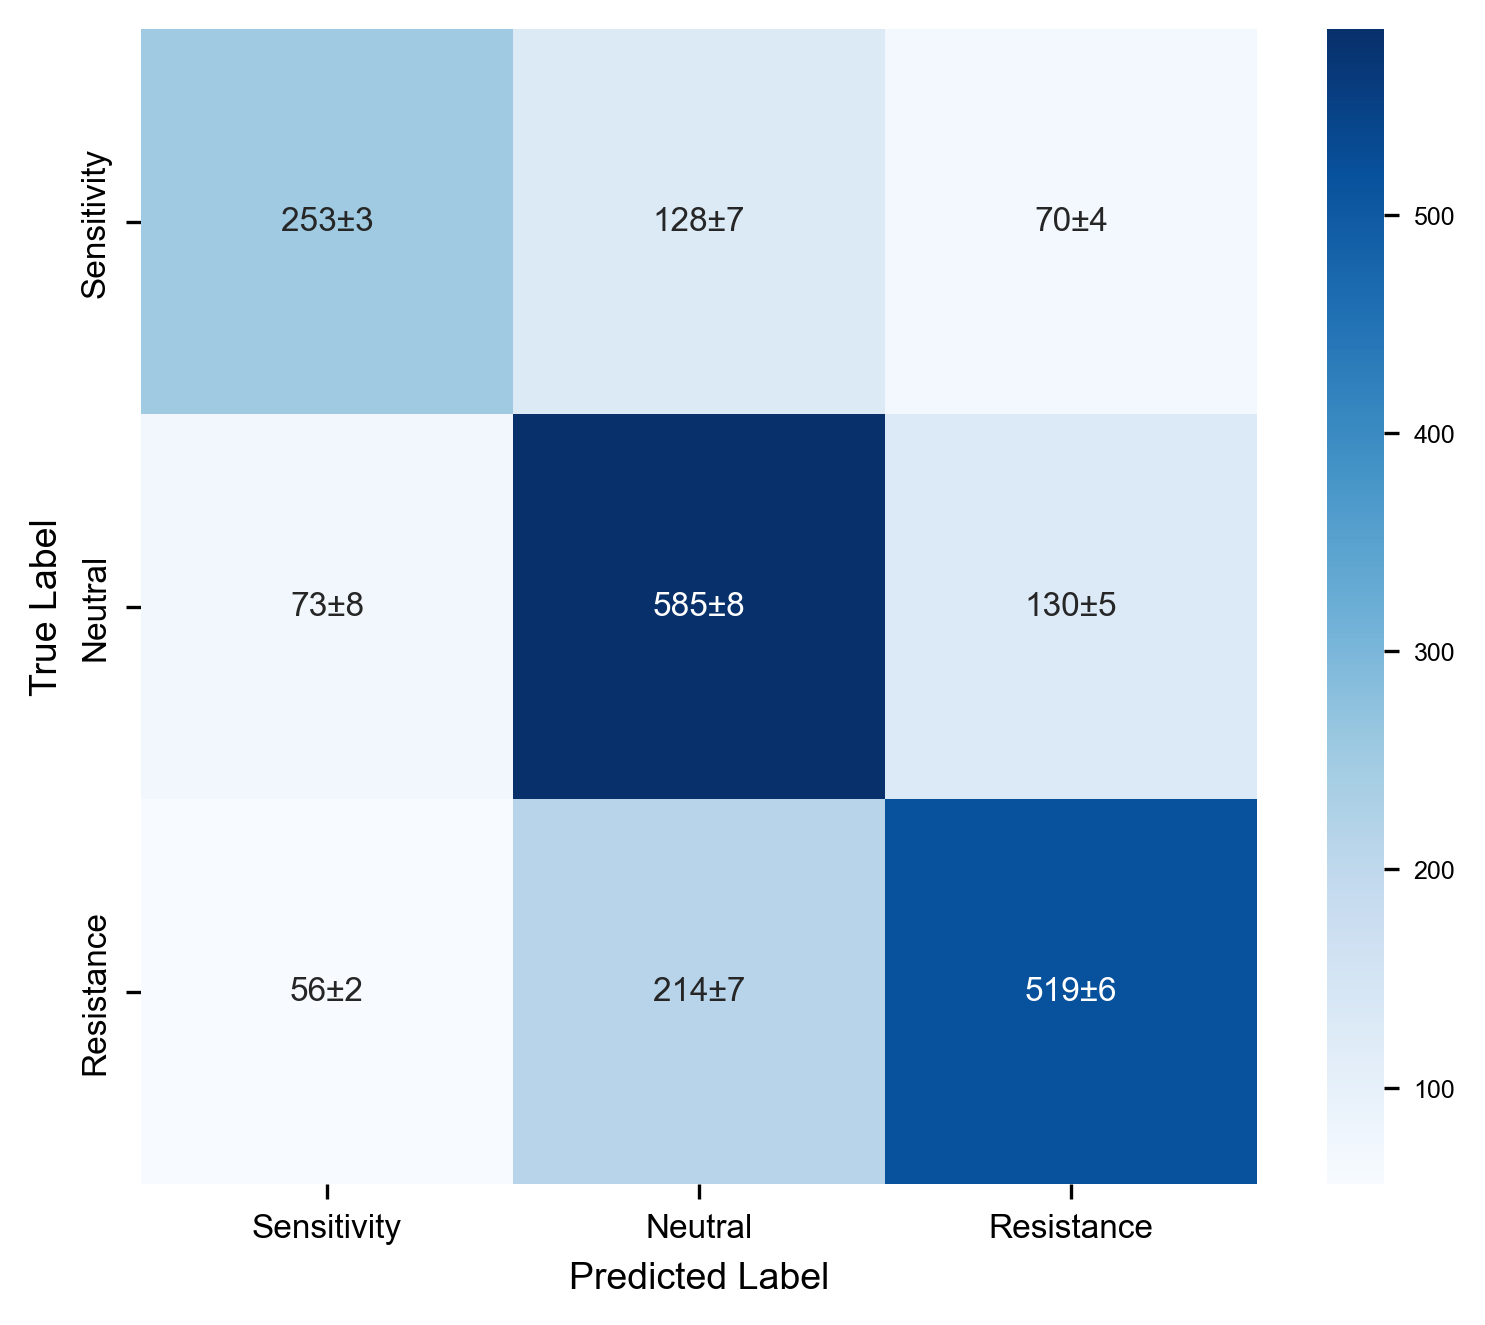

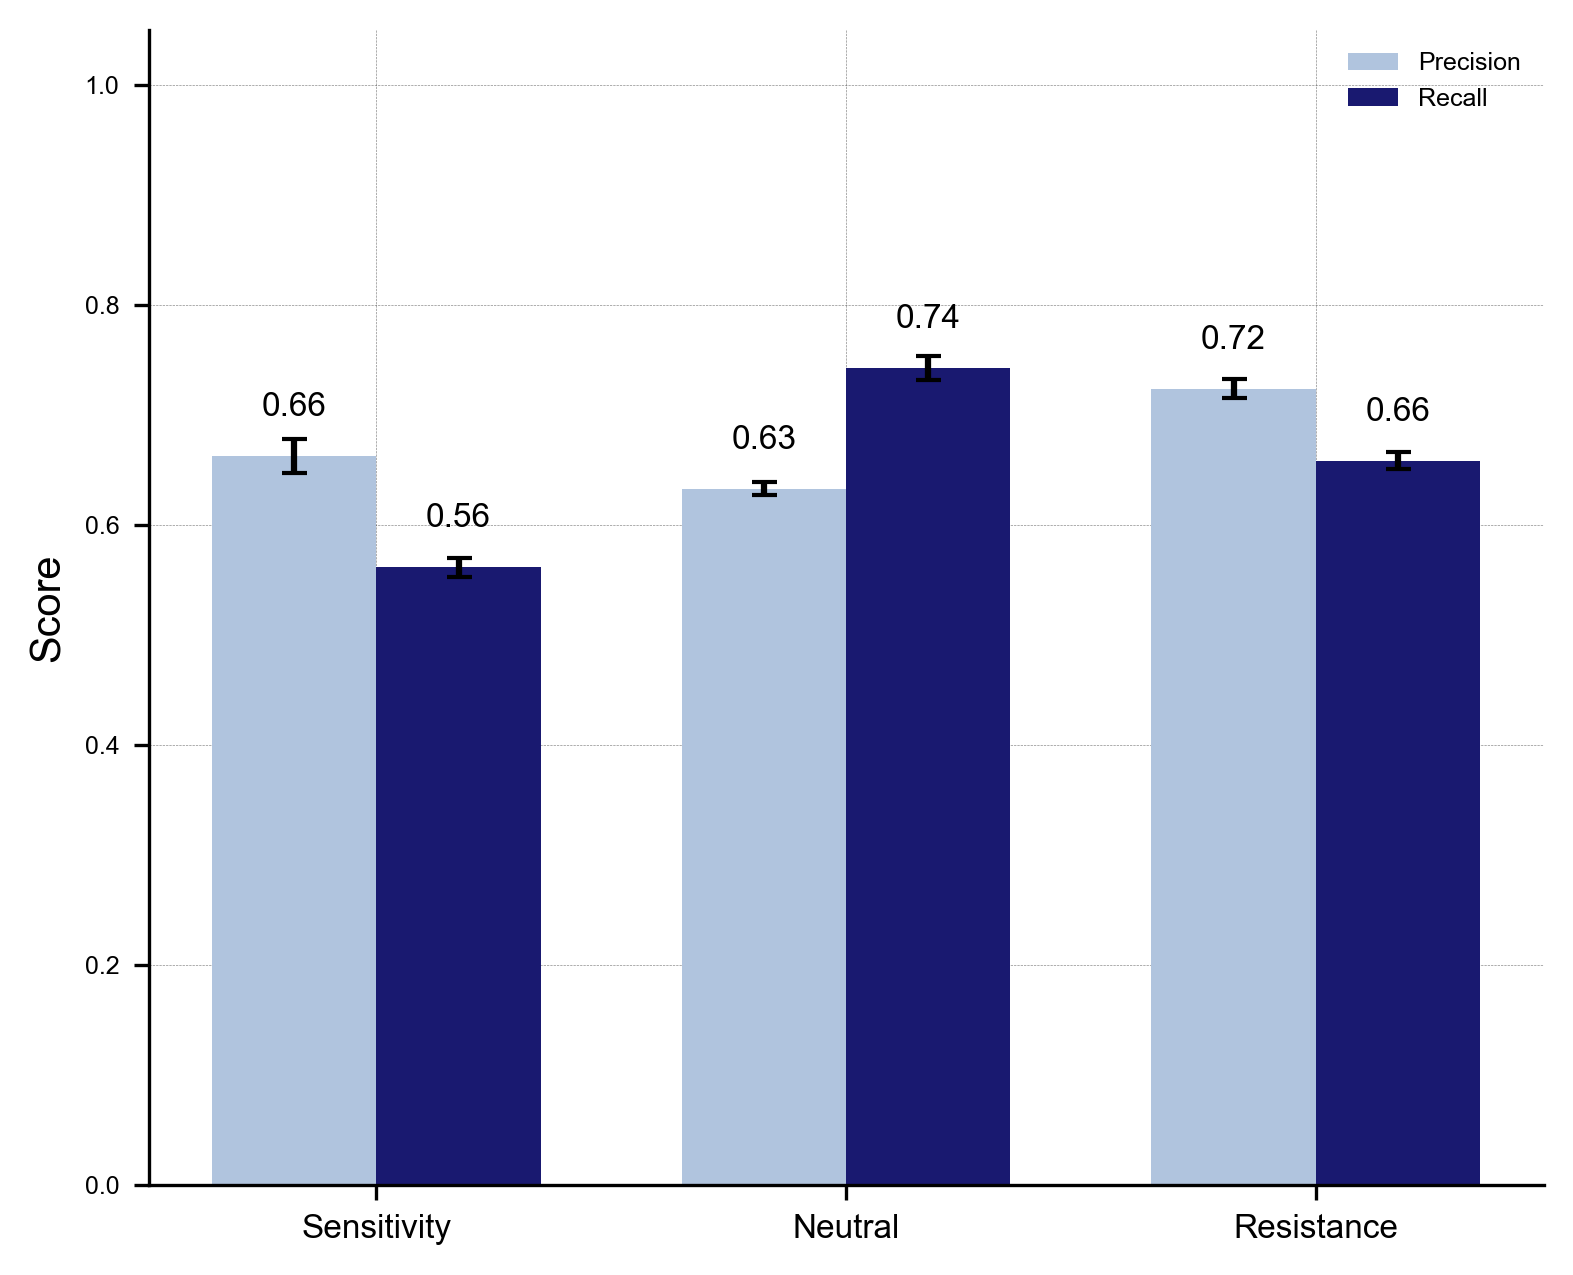

In [107]:
metrics_summary, cm_mean, cm_std = summarize_results(all_metrics, all_cms,
                                                     class_names=le.classes_)

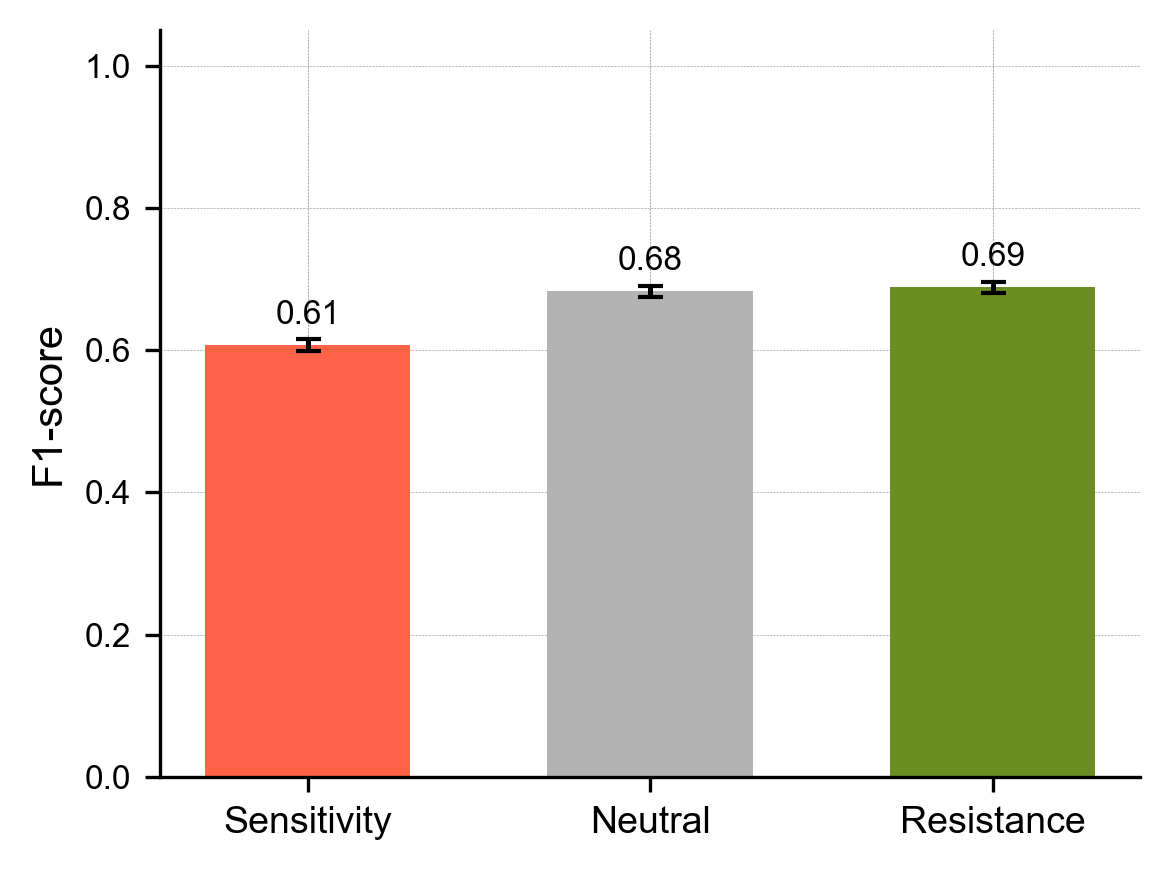

In [85]:
import matplotlib.pyplot as plt
import numpy as np

# Define your desired class order
class_order = ["Sensitivity", "Neutral", "Resistance"]

# Compute mean and std in that order
f1_means = [np.mean([m[f"f1_{c}"] for m in all_metrics]) for c in class_order]
f1_stds  = [np.std([m[f"f1_{c}"] for m in all_metrics]) for c in class_order]

# Define consistent colors for each class
colors_bar = ["tomato", "#b3b3b3", "olivedrab"]

x = np.arange(len(class_order))
plt.figure(figsize=(4,3))

bars = plt.bar(x, f1_means, yerr=f1_stds, capsize=3, color=colors_bar, width = 0.6, error_kw=dict(ecolor='black', lw=1.2))

# Add value labels
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.02, f"{height:.2f}", ha='center', va='bottom', fontsize=8)

plt.xticks(x, class_order, fontsize=9)
plt.ylabel("F1-score", fontsize=10)
plt.yticks(fontsize=8)
plt.ylim(0, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [72]:
#Save the dataset used for the F1 plot
f1_results_to_plot_df = pd.DataFrame({
    "Class": class_order,
    "F1_mean": f1_means,
    "F1_std": f1_stds
})

f1_results_to_plot_df.to_csv("/Users/carolinapinto/desktop/Tese/f1_scores_across_10_runs_plot.csv", index=False)

In [73]:
f1_results_to_plot_df

,Class,F1_mean,F1_std
0,Sensitivity,0.606340,0.003927
1,Neutral,0.686327,0.004821
2,Resistance,0.684308,0.003563


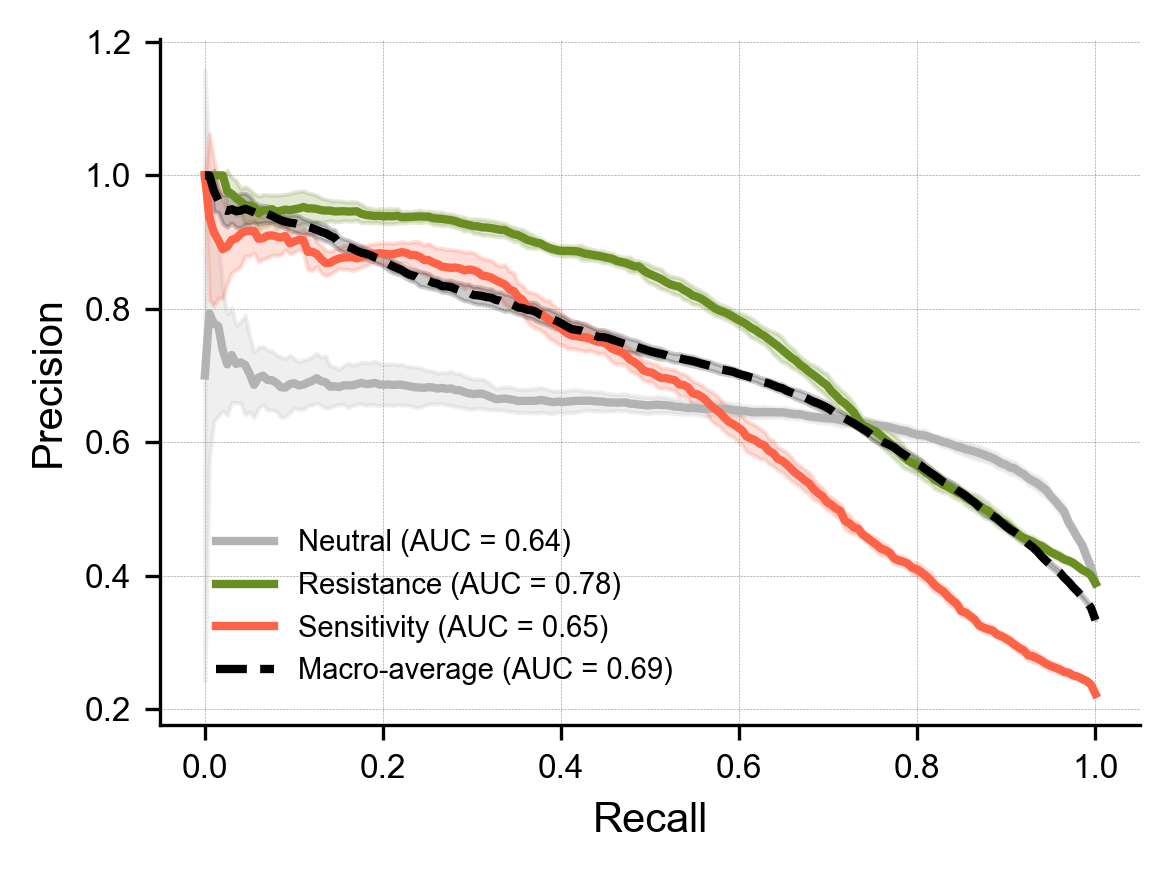

In [86]:
#PR curve
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve, average_precision_score
import numpy as np
import matplotlib.pyplot as plt

classes_for_binarize = np.arange(len(le.classes_))
colors = ["#b3b3b3", "olivedrab", "tomato"]
recall_grid = np.linspace(0, 1, 200)

plt.figure(figsize=(4,3))

for i, class_name in enumerate(le.classes_):
    precisions_interp = []
    aucs = []
    for y_true, probs in zip(all_y_true_runs, all_probs_runs):
        y_true_bin = label_binarize(y_true, classes=classes_for_binarize)
        precision, recall, _ = precision_recall_curve(y_true_bin[:, i], probs[:, i])
        auc = average_precision_score(y_true_bin[:, i], probs[:, i])
        aucs.append(auc)
        precisions_interp.append(np.interp(recall_grid, recall[::-1], precision[::-1]))

    mean_precision = np.mean(precisions_interp, axis=0)
    std_precision  = np.std(precisions_interp, axis=0)
    mean_auc = np.mean(aucs)
    std_auc = np.std(aucs)

    plt.plot(recall_grid, mean_precision, color=colors[i], lw=2, label=f"{class_name} (AUC = {mean_auc:.2f})")
    plt.fill_between(recall_grid, mean_precision - std_precision, mean_precision + std_precision,
                     color=colors[i], alpha=0.2)

# Macro-average
macro_precisions = []
macro_aucs = []
for y_true, probs in zip(all_y_true_runs, all_probs_runs):
    y_true_bin = label_binarize(y_true, classes=classes_for_binarize)
    precision, recall, _ = precision_recall_curve(y_true_bin.ravel(), probs.ravel())
    macro_precisions.append(np.interp(recall_grid, recall[::-1], precision[::-1]))
    macro_aucs.append(average_precision_score(y_true_bin, probs, average="macro"))


mean_macro = np.mean(macro_precisions, axis=0)
std_macro = np.std(macro_precisions, axis=0)
mean_auc_macro = np.mean(macro_aucs)
std_auc_macro = np.std(macro_aucs)


plt.plot(recall_grid, mean_macro, color='black', lw=2, linestyle='--', label=f"Macro-average (AUC = {mean_auc_macro:.2f})")
plt.fill_between(recall_grid, mean_macro - std_macro, mean_macro + std_macro, color='black', alpha=0.2)

plt.xlabel("Recall", fontsize=10)
plt.xticks(fontsize=8)
plt.ylabel("Precision", fontsize=10)
plt.yticks(fontsize=8)
plt.legend(fontsize=7, loc="lower left", frameon=False, bbox_to_anchor=(0.03, 0.02))
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

In [77]:
#Save PR curve data for reproducibility
classes_for_binarize = np.arange(len(le.classes_))
colors = ["#b3b3b3", "olivedrab", "tomato"]
recall_grid = np.linspace(0, 1, 200)

#Store all PR curves data 
all_pr_dfs = []
for i, class_name in enumerate(le.classes_):
    precisions_interp = []
    aucs = []
    for y_true, probs in zip(all_y_true_runs, all_probs_runs):
        y_true_bin = label_binarize(y_true, classes=classes_for_binarize)
        precision, recall, _ = precision_recall_curve(y_true_bin[:, i], probs[:, i])
        auc = average_precision_score(y_true_bin[:, i], probs[:, i])
        aucs.append(auc)
        precisions_interp.append(np.interp(recall_grid, recall[::-1], precision[::-1]))

    mean_precision = np.mean(precisions_interp, axis=0)
    std_precision  = np.std(precisions_interp, axis=0)
    mean_auc = np.mean(aucs)
    std_auc = np.std(aucs)

    #Dataframe with the per-class PR curve data for reproducibility
    df_class = pd.DataFrame({
        "Recall": recall_grid,
        "Mean_Precision": mean_precision,
        "Std_Precision": std_precision,
        "Class": class_name,
        "Mean_AUC": mean_auc,
        "Std_AUC": std_auc
    })
    all_pr_dfs.append(df_class)

# Macro-average
macro_precisions = []
macro_aucs = []
for y_true, probs in zip(all_y_true_runs, all_probs_runs):
    y_true_bin = label_binarize(y_true, classes=classes_for_binarize)
    precision, recall, _ = precision_recall_curve(y_true_bin.ravel(), probs.ravel())
    macro_precisions.append(np.interp(recall_grid, recall[::-1], precision[::-1]))
    macro_aucs.append(average_precision_score(y_true_bin, probs, average="macro"))


mean_macro = np.mean(macro_precisions, axis=0)
std_macro = np.std(macro_precisions, axis=0)
mean_auc_macro = np.mean(macro_aucs)
std_auc_macro = np.std(macro_aucs)

df_macro = pd.DataFrame({
    "Recall": recall_grid,
    "Mean_Precision": mean_macro,
    "Std_Precision": std_macro,
    "Class": "Macro-average",
    "Mean_AUC": mean_auc_macro,
    "Std_AUC": std_auc_macro
})
all_pr_dfs.append(df_macro)

#Combine all into a single dataframe
pr_curve_data_df = pd.concat(all_pr_dfs, ignore_index=True)
pr_curve_data_df.to_csv("/Users/carolinapinto/desktop/Tese/pr_curve_data_across_10_runs_plot.csv", index=False)


In [78]:
pr_curve_data_df.head()

,Recall,Mean_Precision,Std_Precision,Class,Mean_AUC,Std_AUC
0,0.000000,0.900000,0.300000,Neutral,0.652565,0.0056
1,0.005025,0.892395,0.138434,Neutral,0.652565,0.0056
2,0.010050,0.879946,0.099061,Neutral,0.652565,0.0056
3,0.015075,0.872920,0.064076,Neutral,0.652565,0.0056
4,0.020101,0.876734,0.054888,Neutral,0.652565,0.0056


#### SHAP

In [ ]:
all_shap_values_runs, all_X_val_runs

In [115]:
len(all_shap_values_runs)

50

In [118]:
all_shap_values_runs[0].shape  #Number of classes

(406, 52, 3)

In [116]:
len(all_X_val_runs)

50

In [119]:
all_X_val_runs[0].shape  #Number of samples x number of features

(406, 52)

In [120]:
def get_stacked_shap_for_class(
    all_shap_values_runs,
    all_X_val_runs,
    le,
    target_class
):
    """
    Stack SHAP values and corresponding feature matrices across
    all CV folds and runs for a given class.
    """
    # Get class index
    class_idx = list(le.classes_).index(target_class)

    shap_blocks = []
    X_blocks = []

    for fold_shap, X_val in zip(all_shap_values_runs, all_X_val_runs):
        # fold_shap shape: (n_samples, n_features, n_classes)
        shap_blocks.append(fold_shap[:, :, class_idx])
        X_blocks.append(X_val)

    shap_c = np.vstack(shap_blocks)
    X_c = pd.concat(X_blocks, axis=0)

    assert shap_c.shape[0] == X_c.shape[0], "Row mismatch after stacking"

    return shap_c, X_c

In [121]:
def top_k_features_by_mean_abs_shap(shap_c, X_c, k=10):
    mean_abs = np.mean(np.abs(shap_c), axis=0)
    s = pd.Series(mean_abs, index=X_c.columns).sort_values(ascending=False)
    return s.head(k)  # returns a Series: index=feature, value=mean|SHAP|

In [122]:
def plot_topk_shap_for_class(all_shap_values_runs, all_X_val_runs, le, target_class, k=10):
    shap_c, X_c = get_stacked_shap_for_class(all_shap_values_runs, all_X_val_runs, le, target_class)

    topk = top_k_features_by_mean_abs_shap(shap_c, X_c, k=k)
    top_features = topk.index.tolist()

    # Subset to top-k features
    cols_idx = [X_c.columns.get_loc(f) for f in top_features]
    shap_top = shap_c[:, cols_idx]
    X_top = X_c[top_features]

    print(f"\n=== {target_class}: Top {k} by mean(|SHAP|) ===")
    print(topk)

    # Bar: mean absolute SHAP
    shap.summary_plot(shap_top, X_top, plot_type="bar", max_display=k)

    # Beeswarm: distribution + direction
    shap.summary_plot(shap_top, X_top, max_display=k)


=== Resistance: Top 10 by mean(|SHAP|) ===
Gene_expression_voom    0.144689
LOEUF                   0.089033
TSL                     0.077356
bStatistic              0.075884
CADD_PHRED              0.066021
ClinPred                0.044016
SpliceAI_pred_DP_AL     0.039150
GERP++_NR               0.034433
SpliceAI_pred_DP_DL     0.030206
DEOGEN2_score           0.029127
dtype: float32


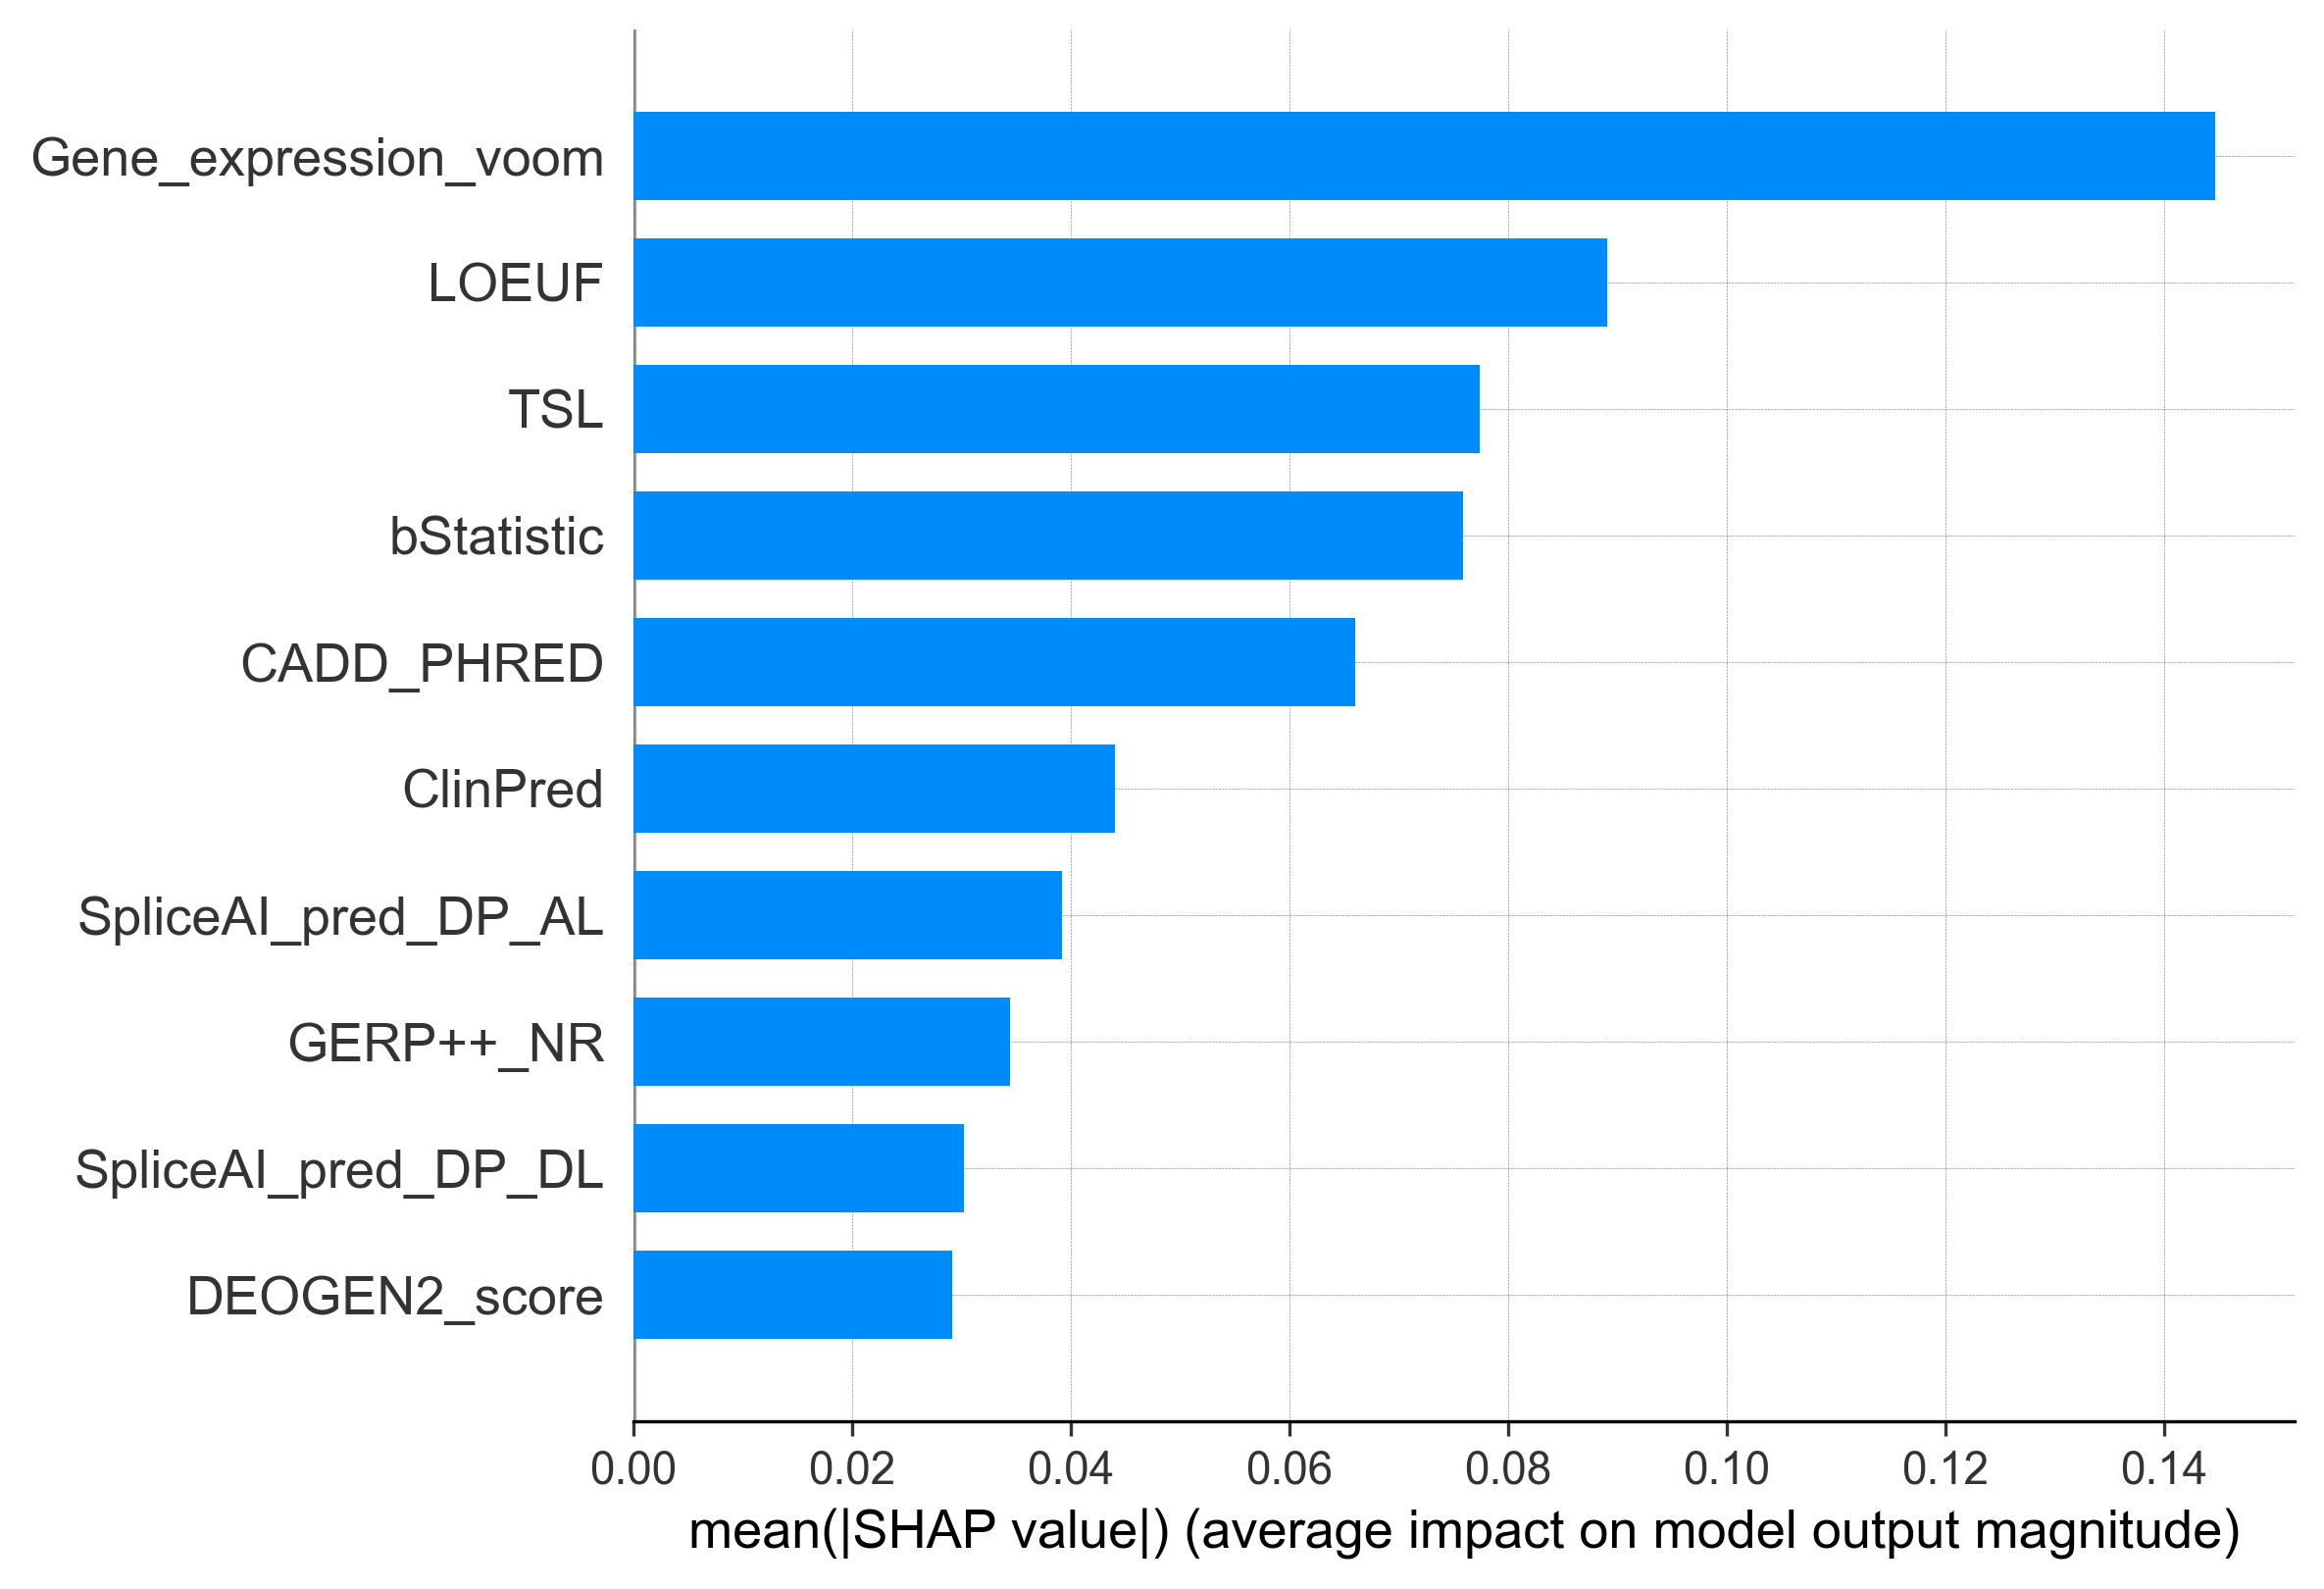

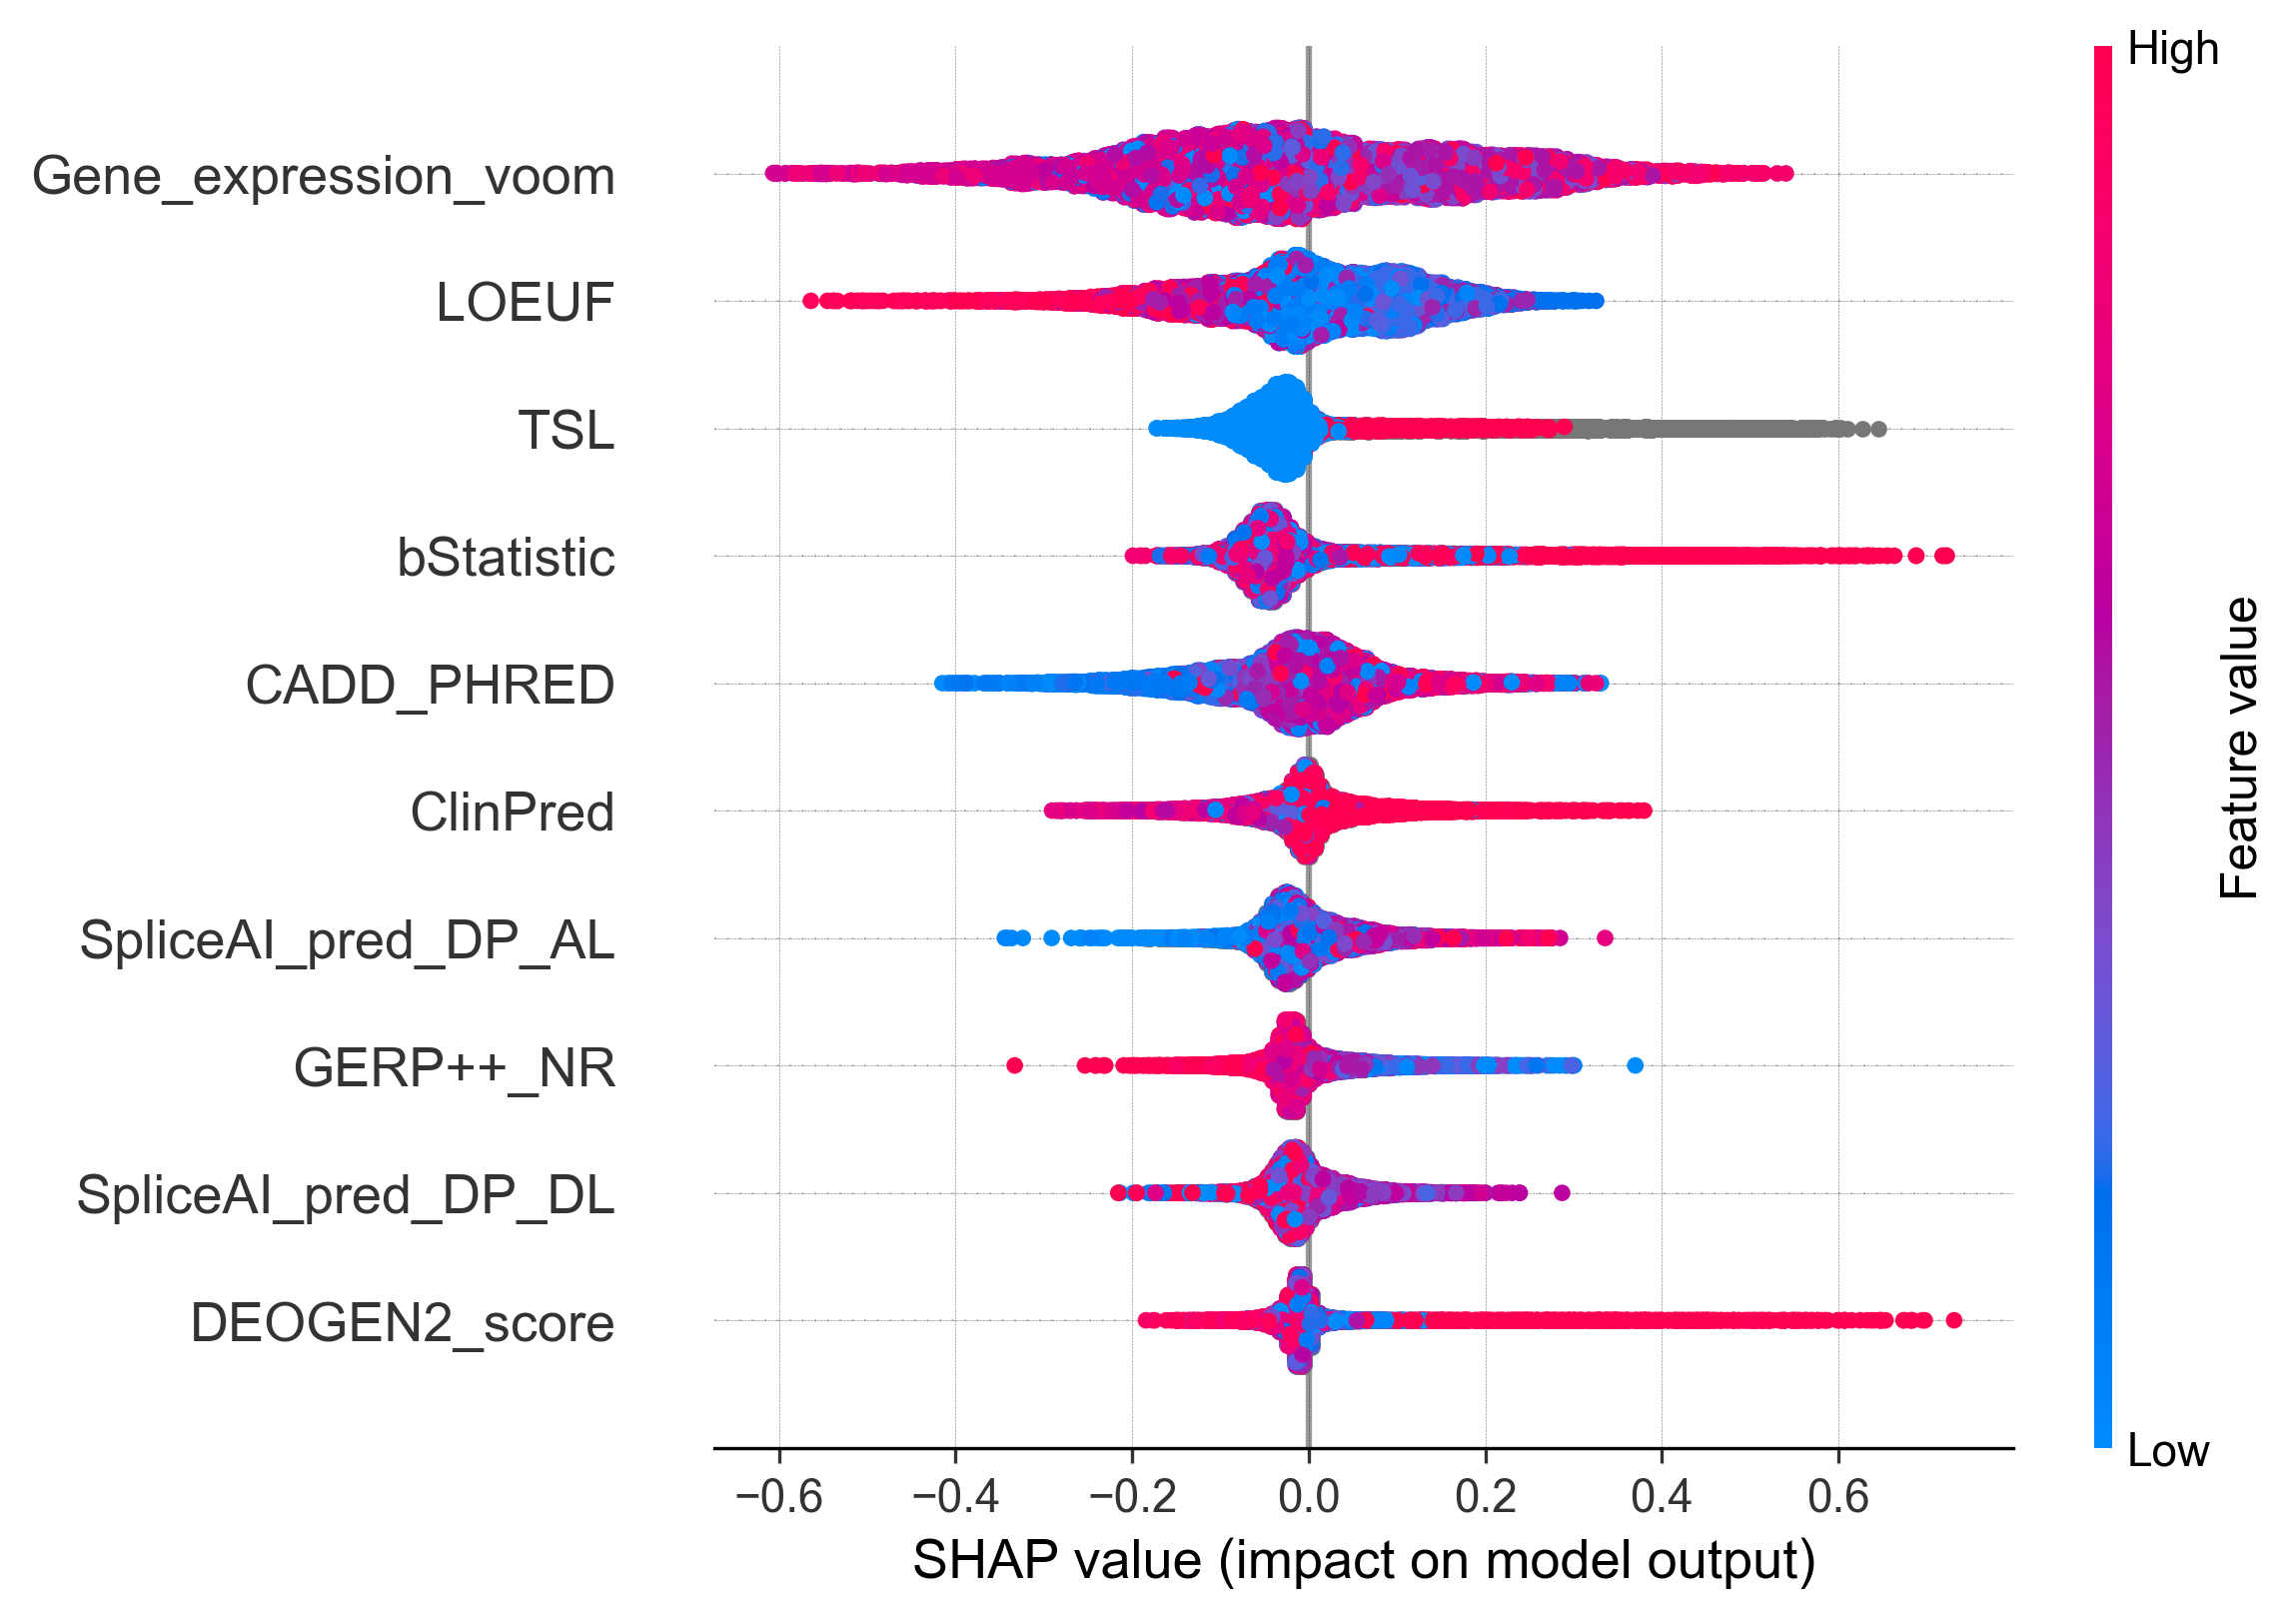

In [123]:
plot_topk_shap_for_class(all_shap_values_runs, all_X_val_runs, le, target_class='Resistance', k=10)

In [129]:
annotated_control_EG['TSL'].value_counts()

TSL
1.0    69954
2.0     2724
Name: count, dtype: int64


=== Sensitivity: Top 10 by mean(|SHAP|) ===
Gene_expression_voom    0.358028
LOEUF                   0.102054
CADD_PHRED              0.076981
SpliceAI_pred_DP_DL     0.033771
bStatistic              0.033359
SpliceAI_pred_DP_DG     0.028793
BayesDel_noAF_score     0.027963
SpliceAI_pred_DP_AL     0.026525
TSL                     0.025968
SpliceAI_pred_DP_AG     0.024300
dtype: float32


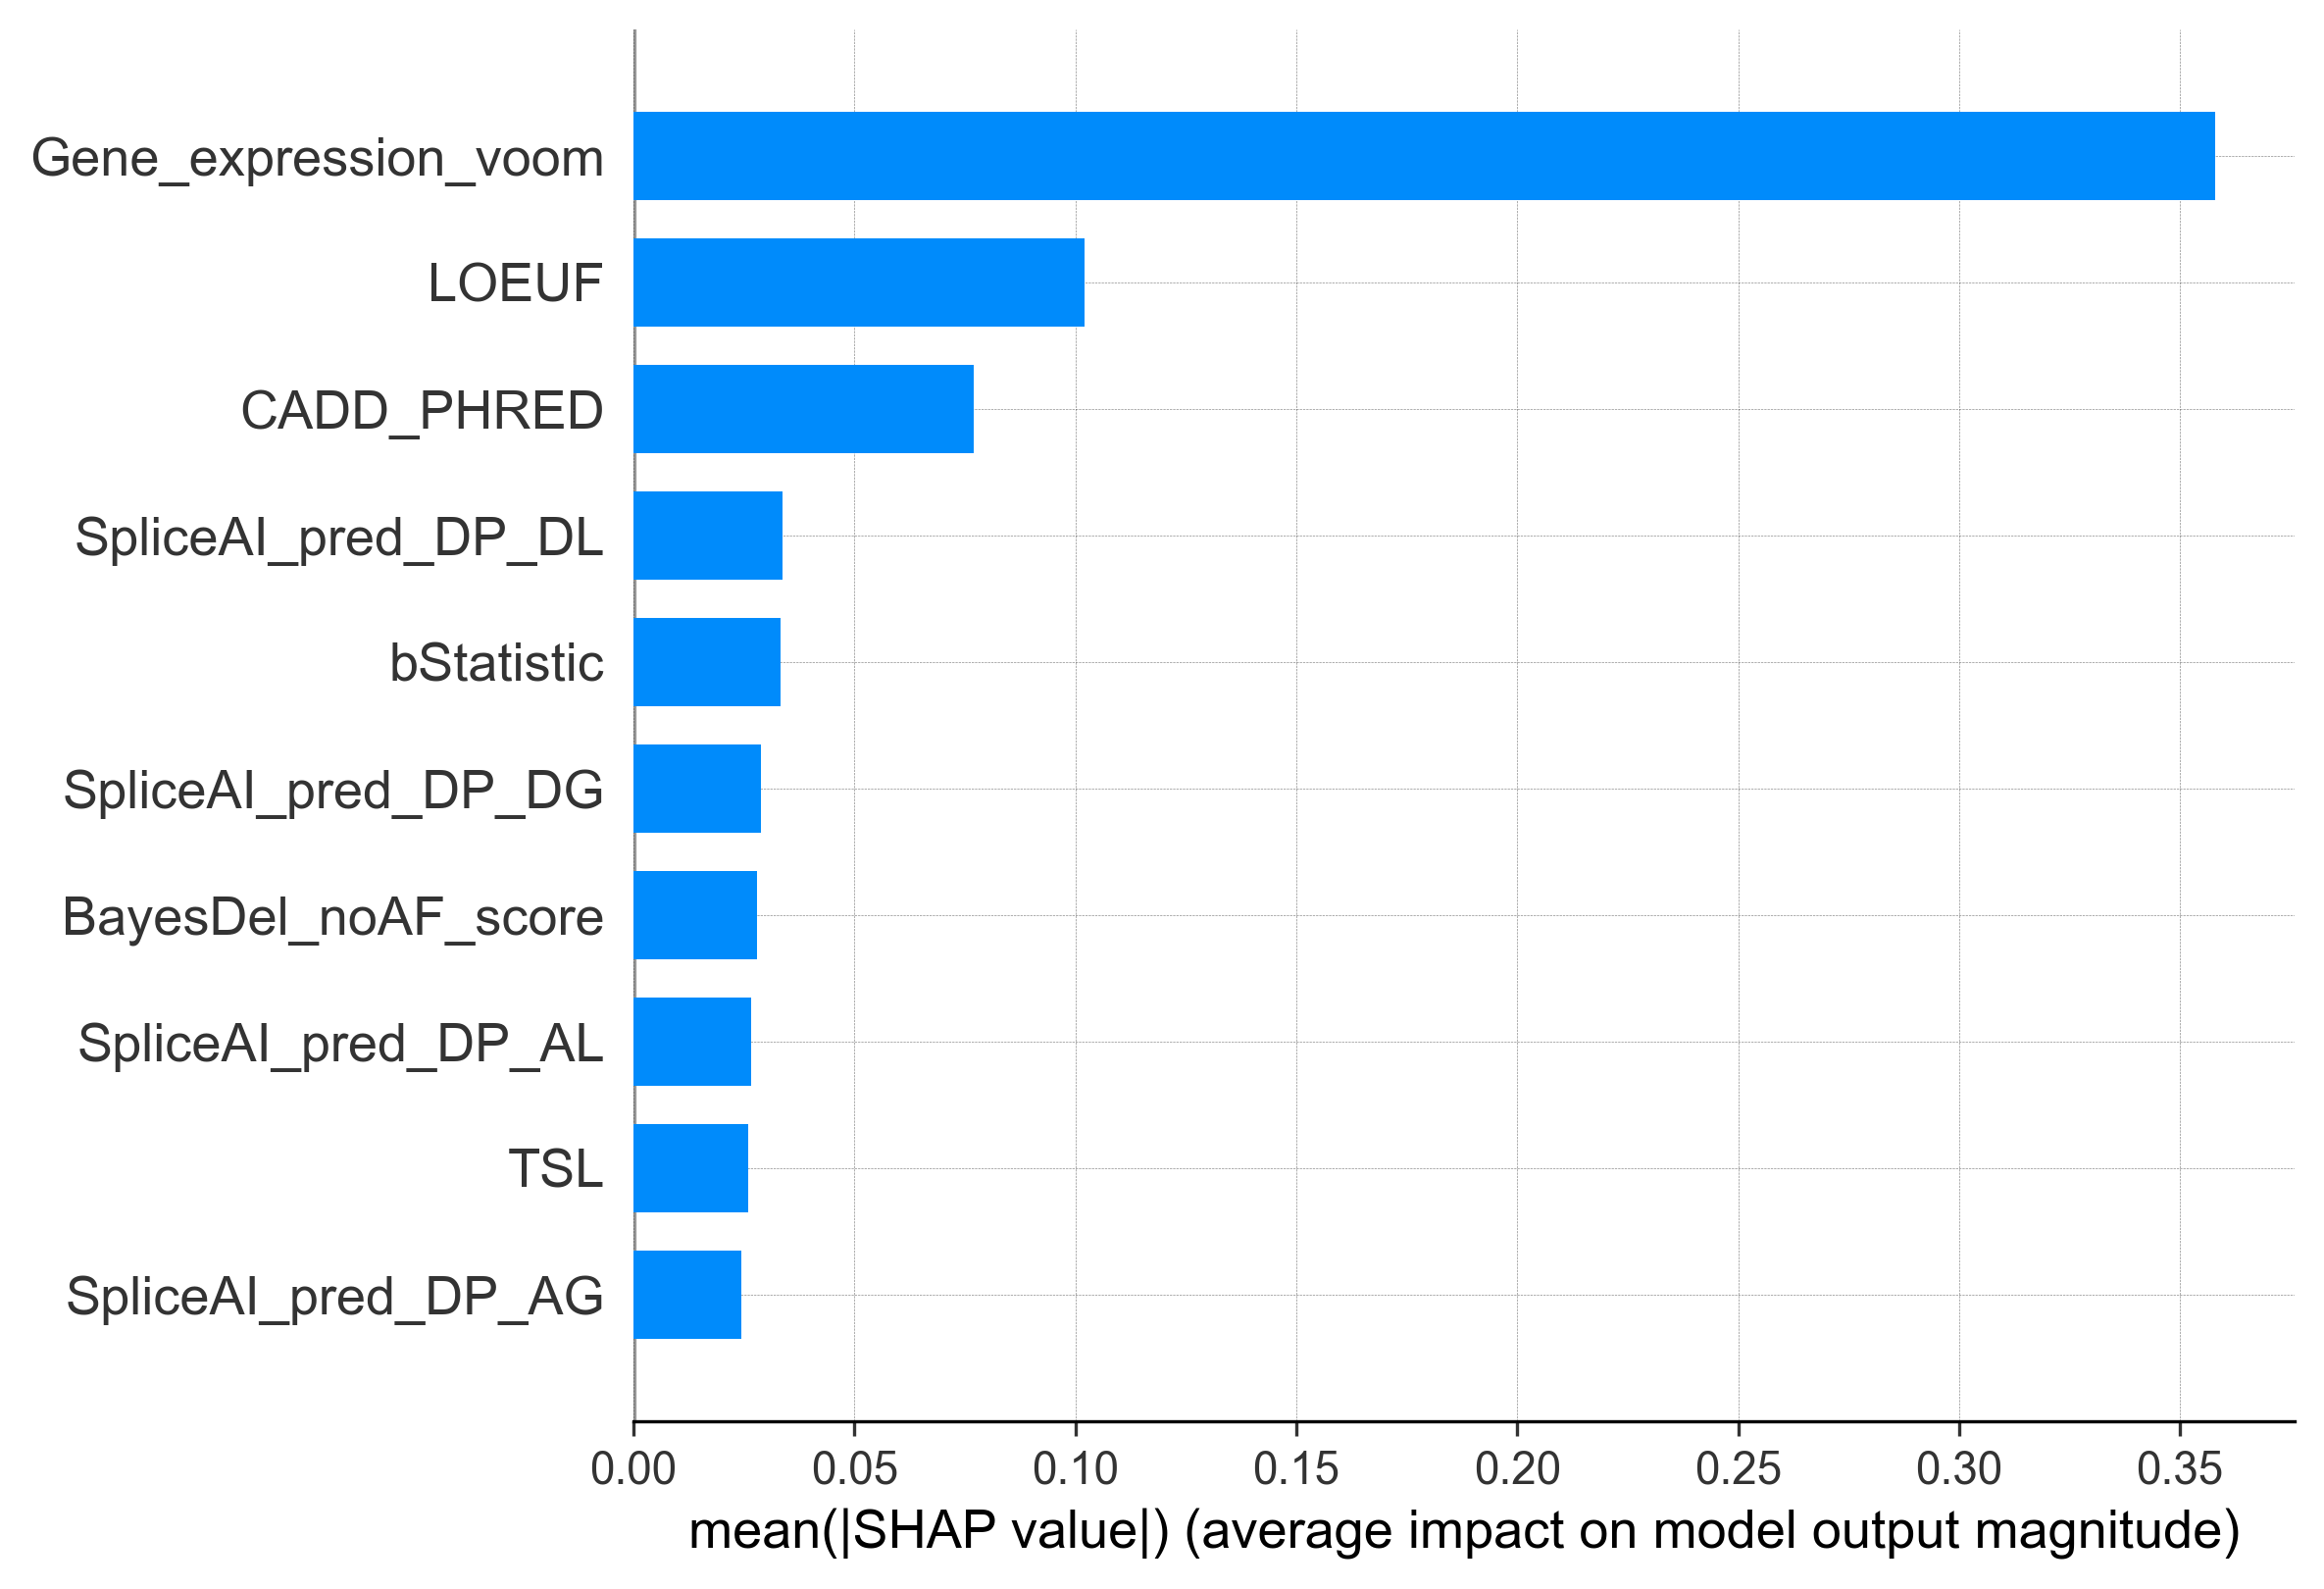

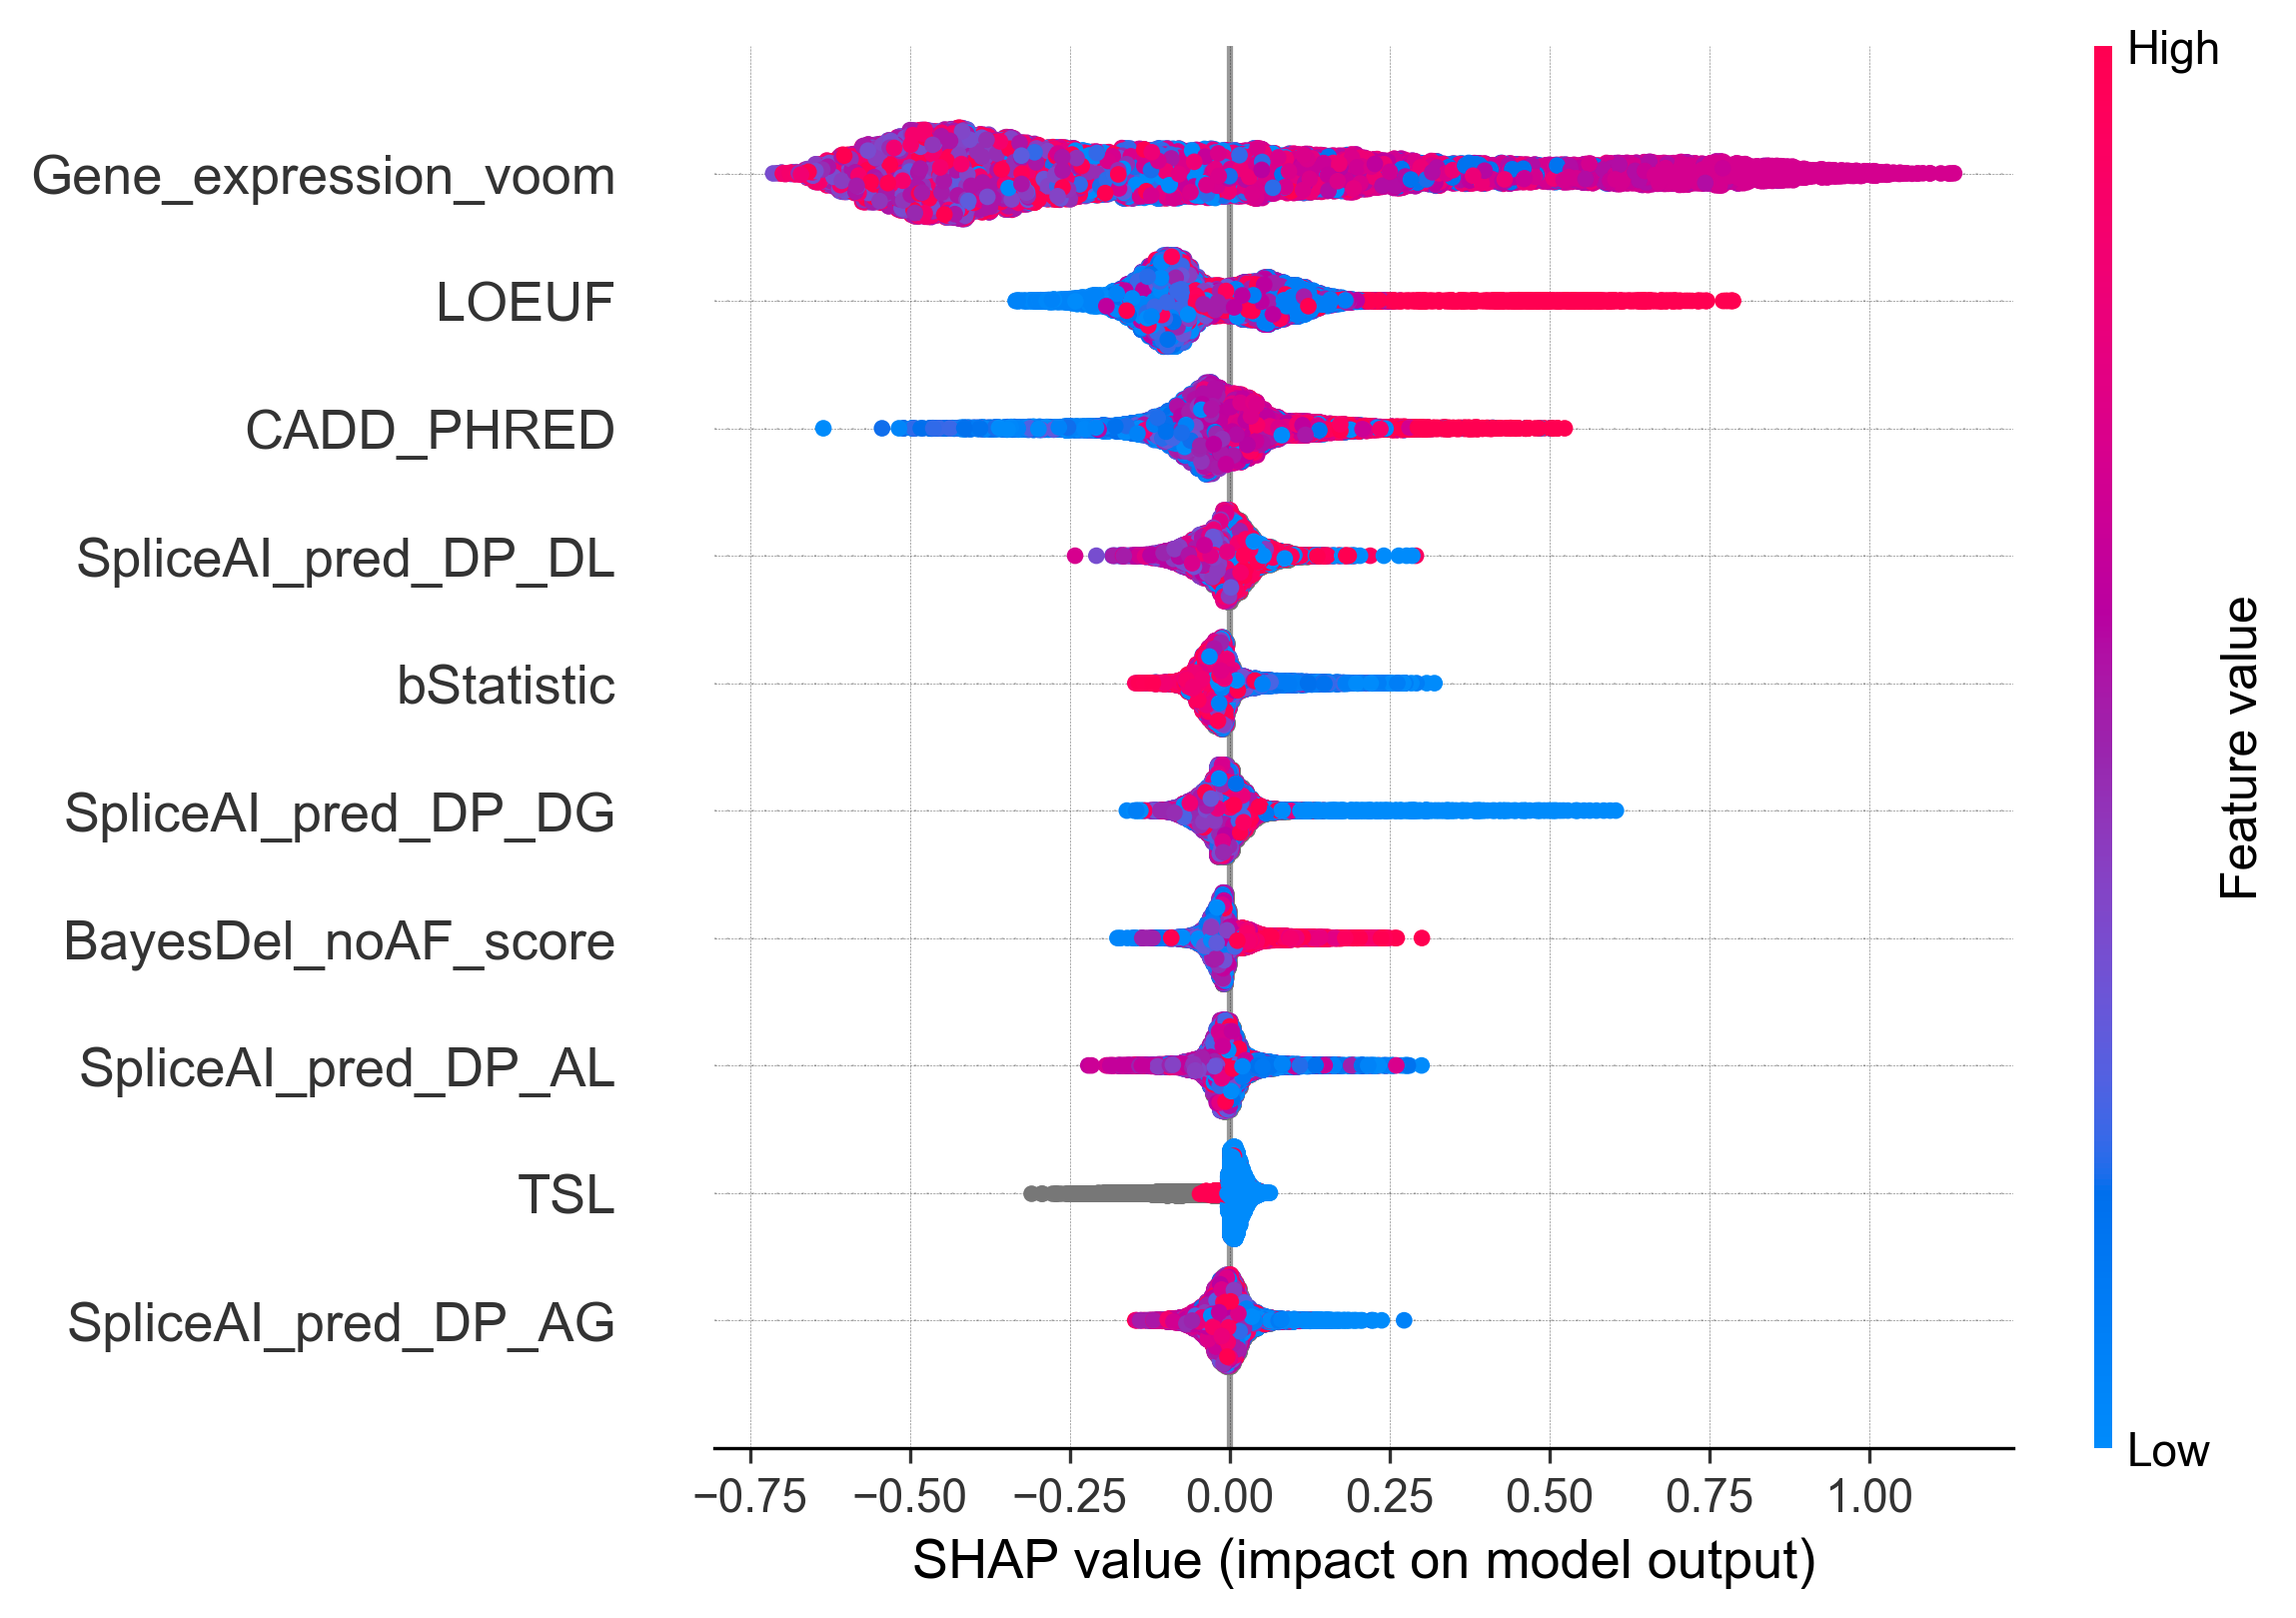

In [124]:
plot_topk_shap_for_class(all_shap_values_runs, all_X_val_runs, le, target_class='Sensitivity', k=10)


=== Neutral: Top 10 by mean(|SHAP|) ===
CADD_PHRED              0.206031
Gene_expression_voom    0.072151
BayesDel_noAF_score     0.064128
LOEUF                   0.056161
AlphaMissense_score     0.050301
VARITY_R_LOO_score      0.039371
MPC_rankscore           0.038072
ClinPred                0.036350
bStatistic              0.034833
gMVP_score              0.030424
dtype: float32


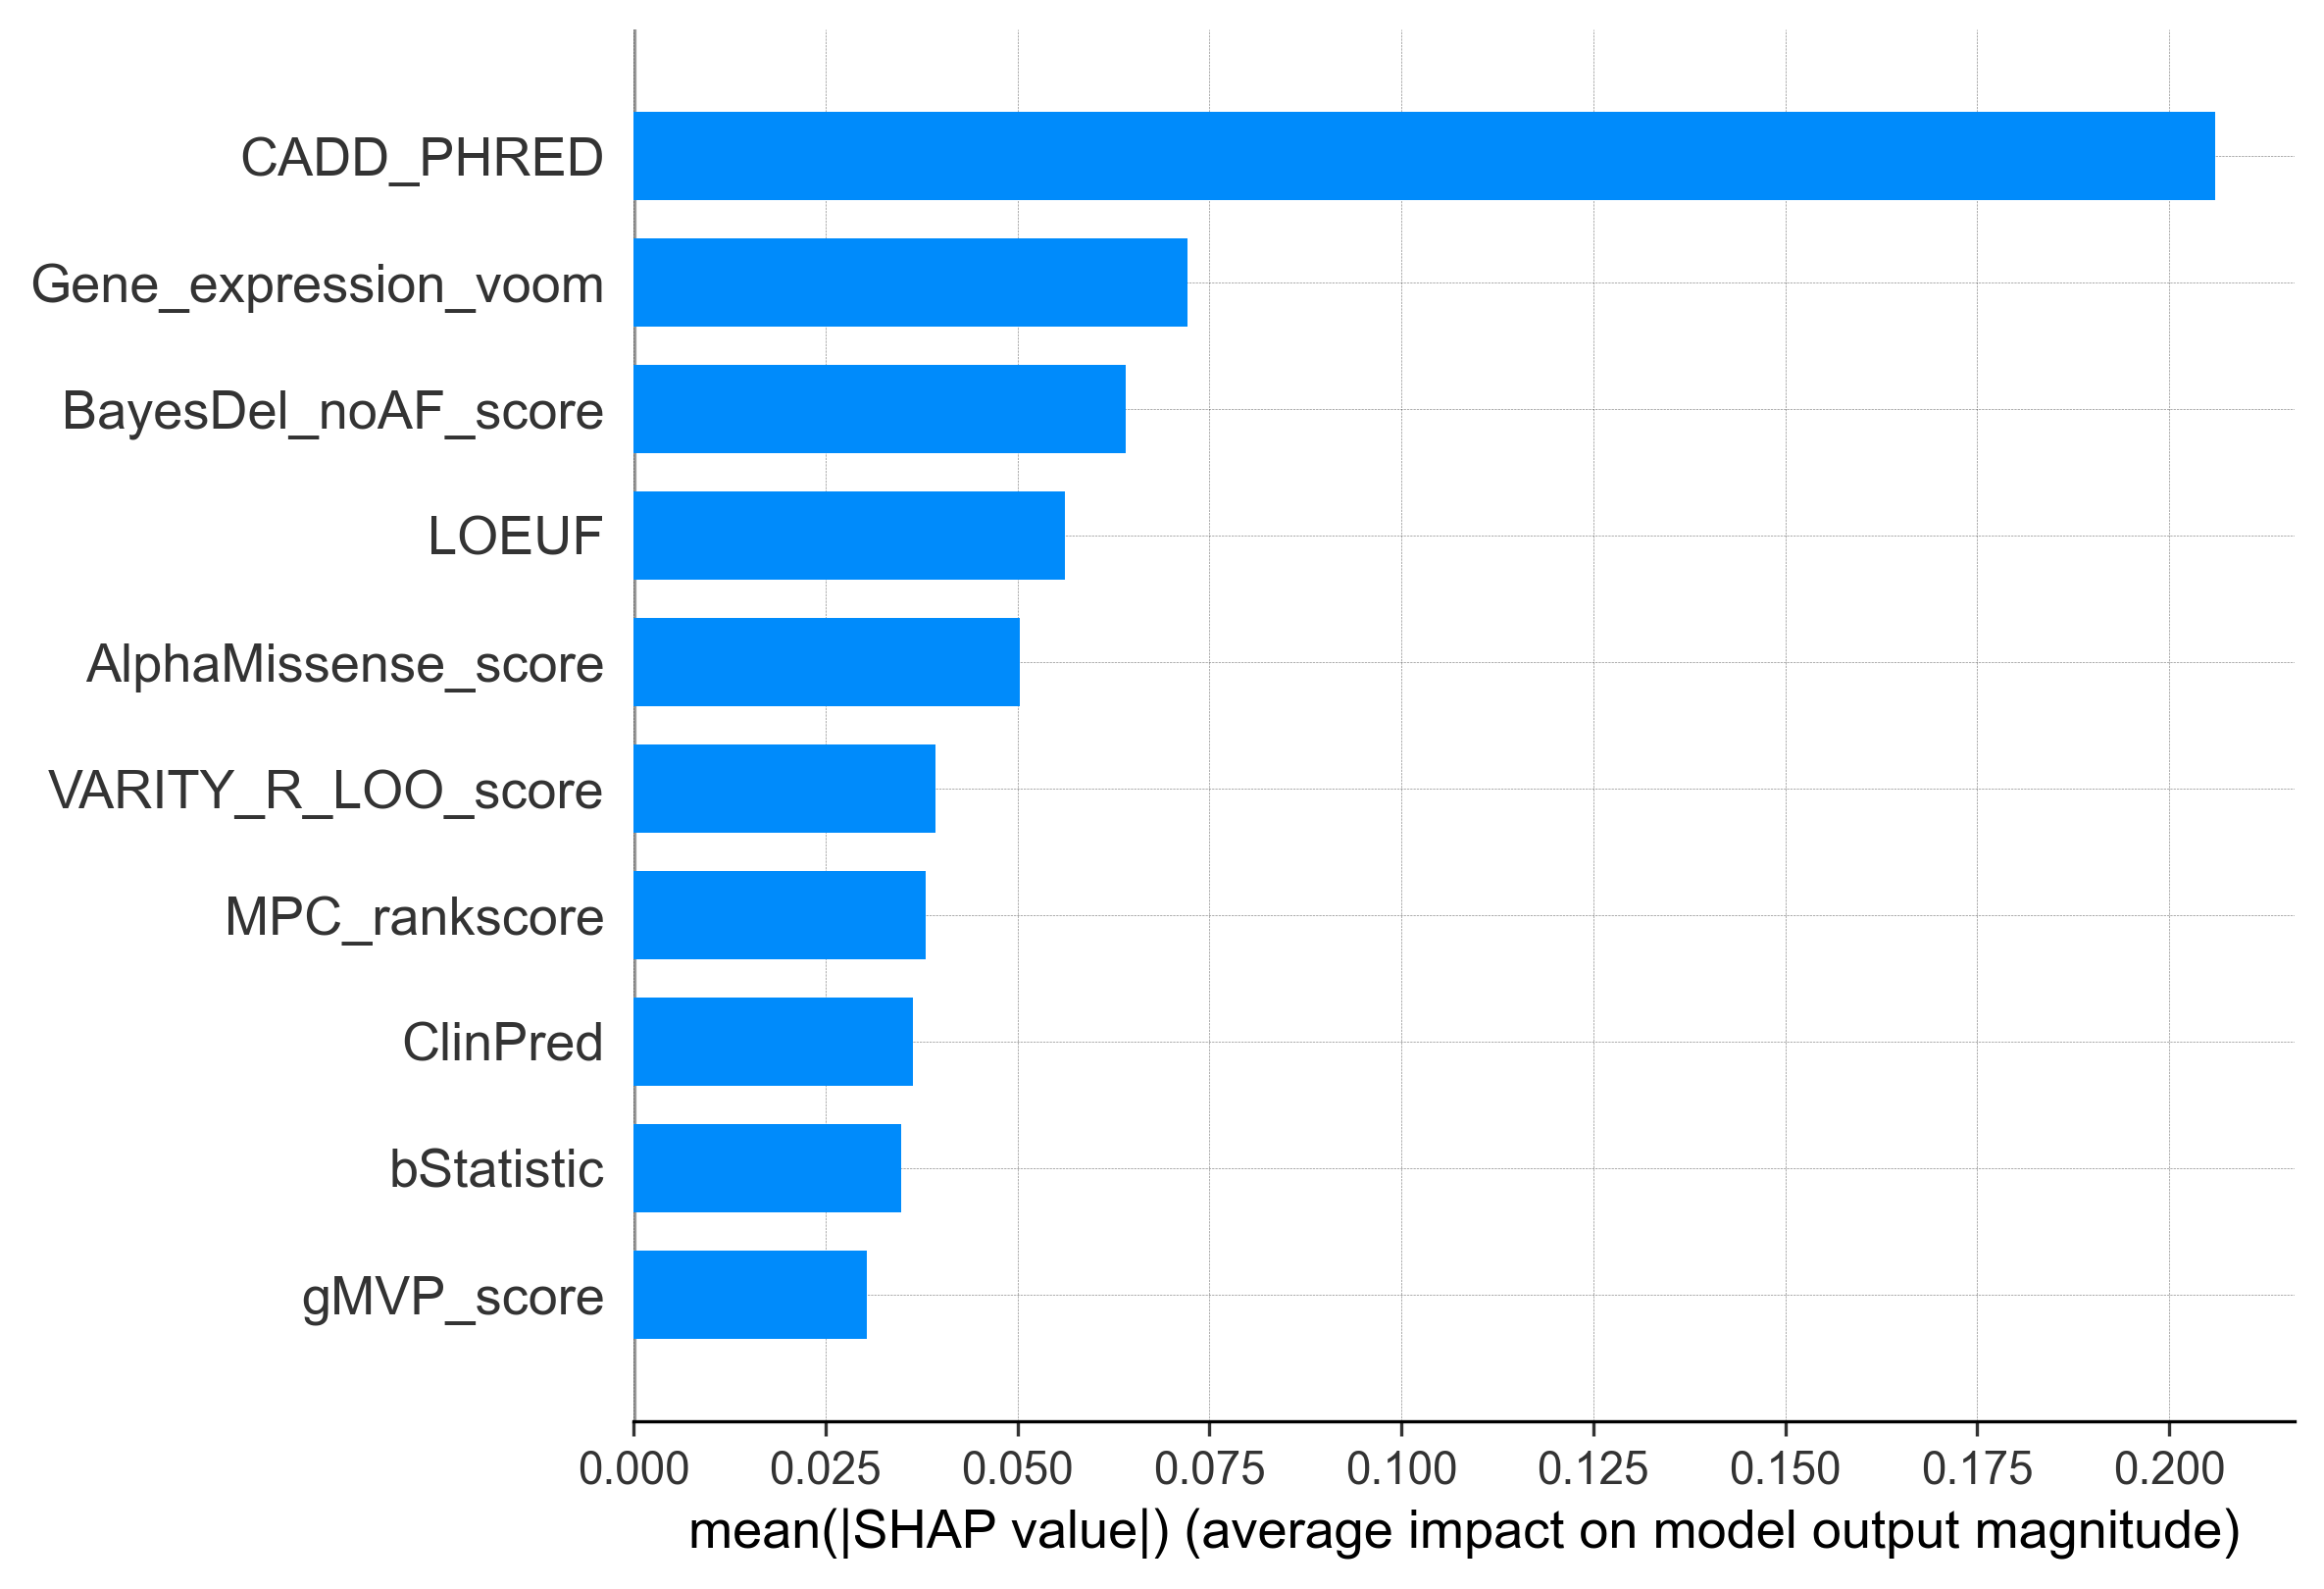

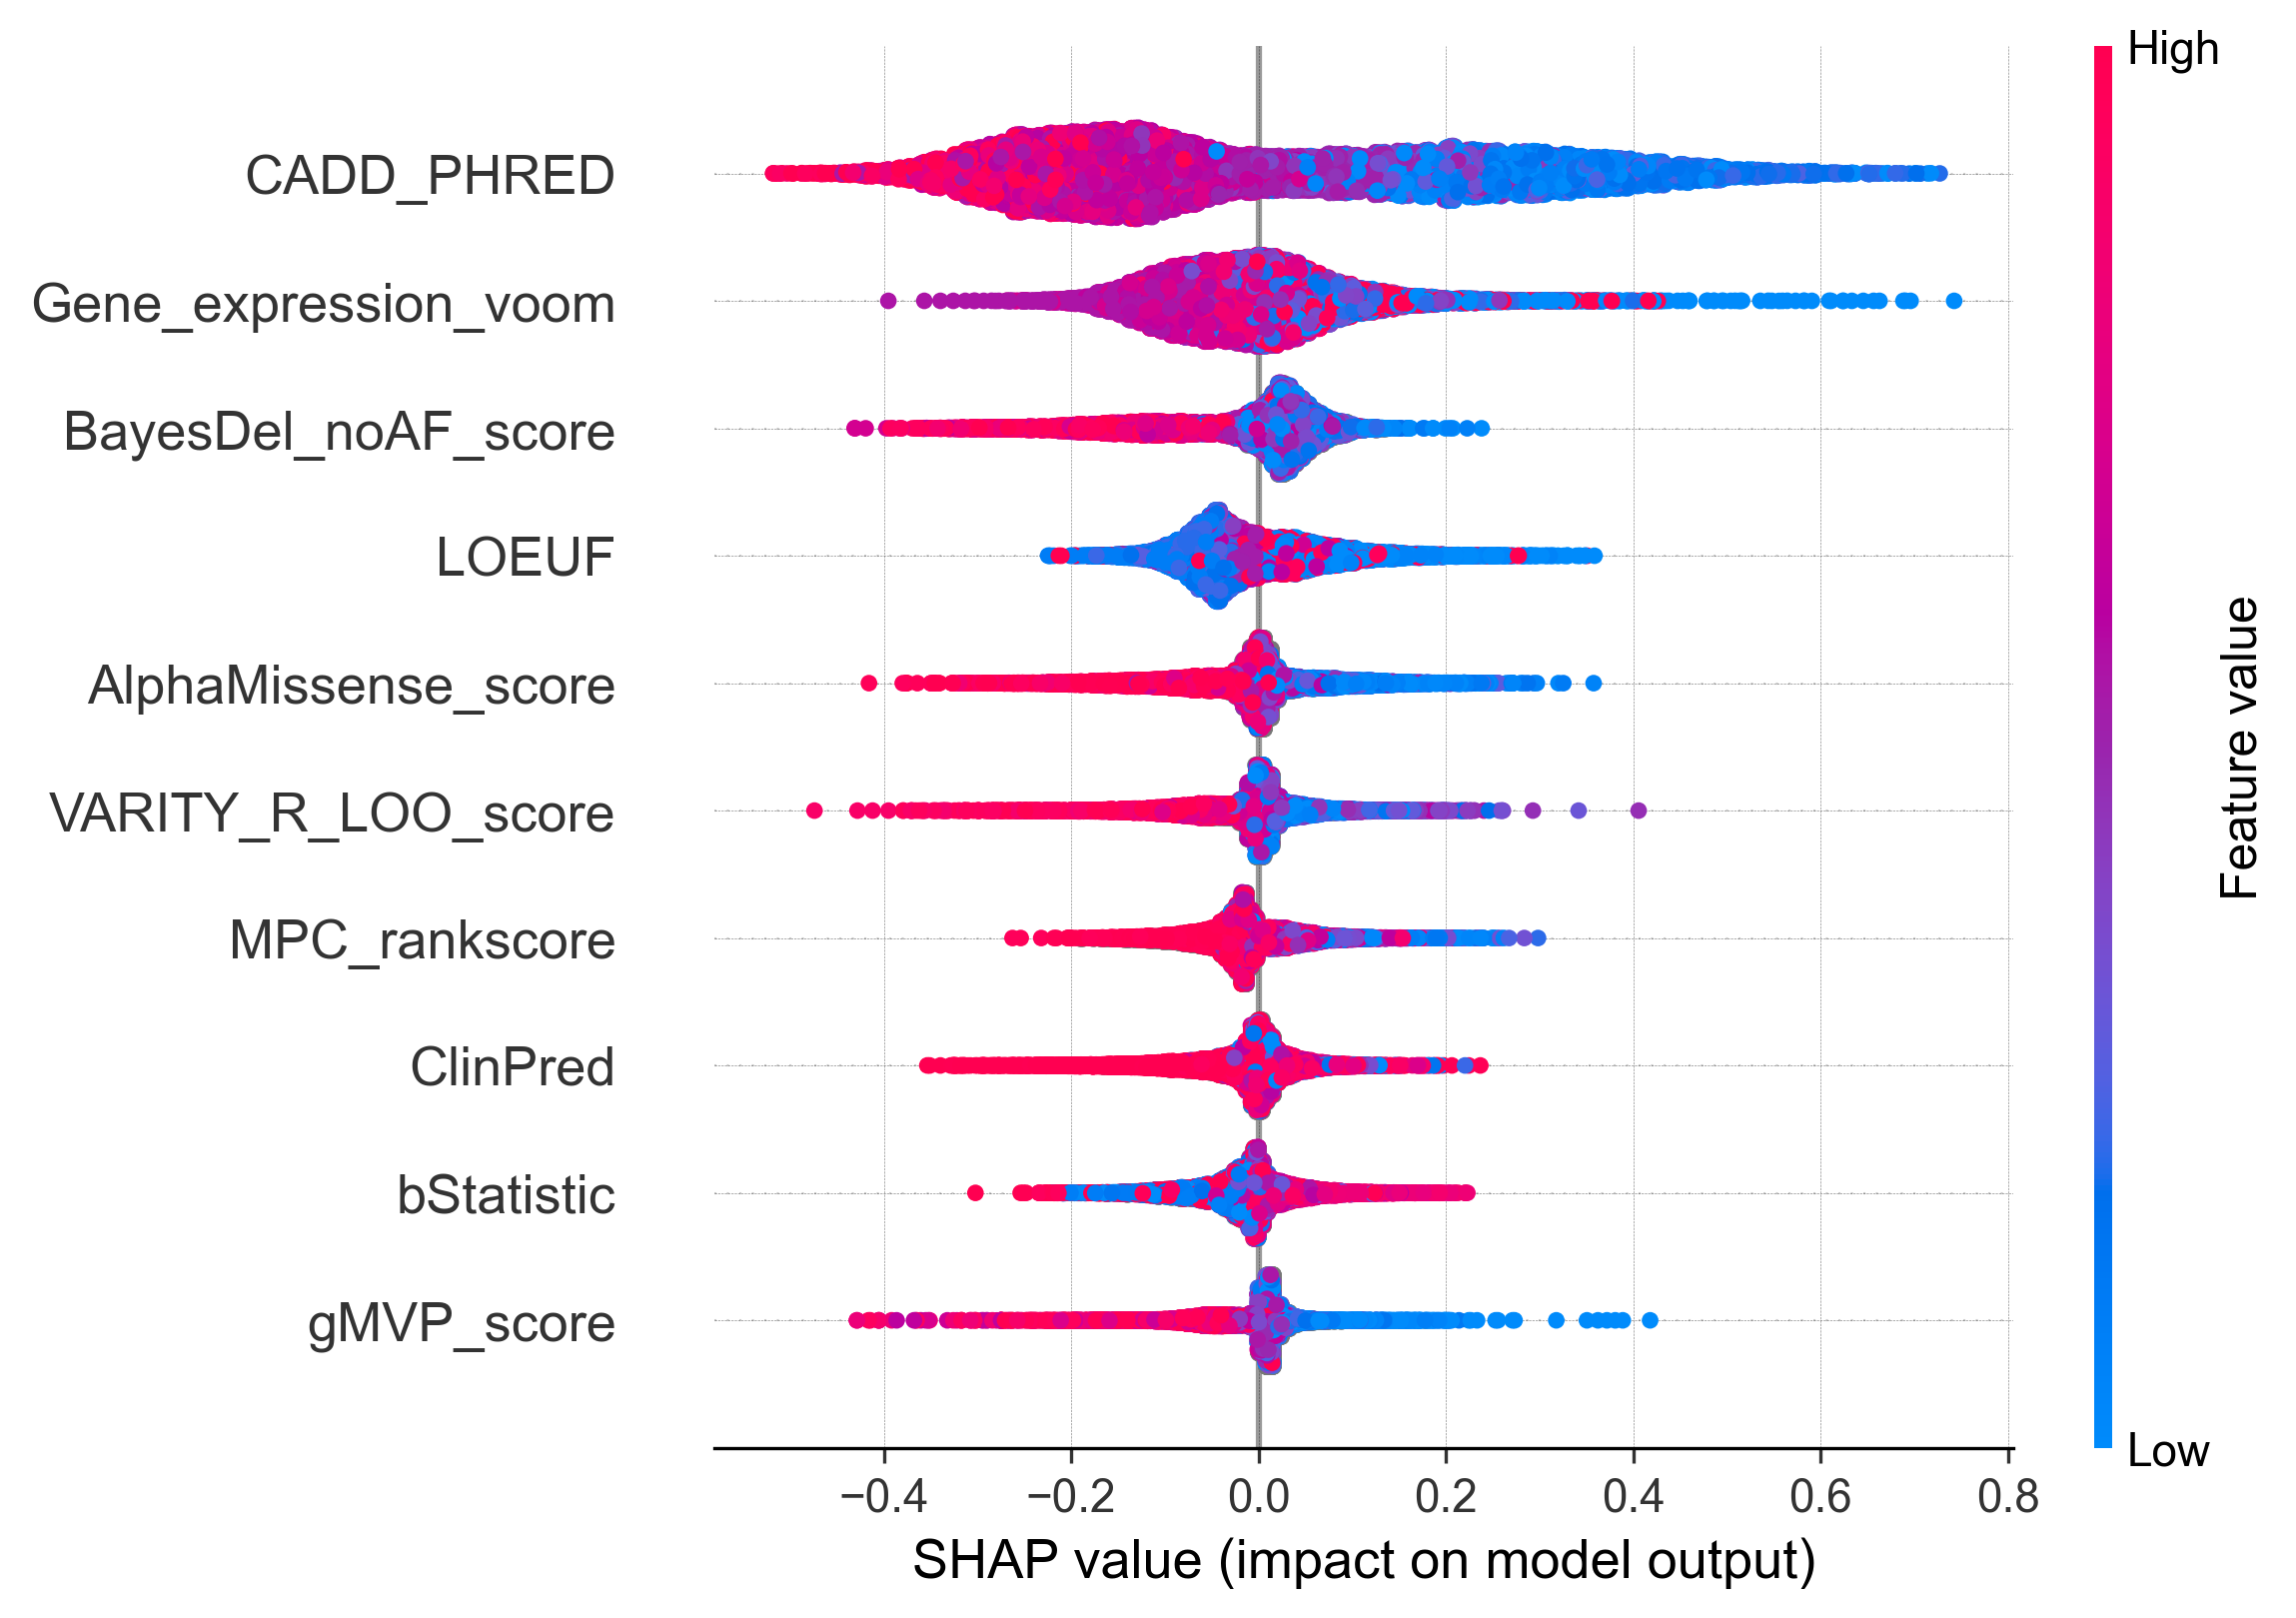

In [125]:
plot_topk_shap_for_class(all_shap_values_runs, all_X_val_runs, le, target_class='Neutral', k=10)

## Random Search 

In [32]:
params = {
    "n_estimators": [50, 100, 200, 300, 500, 700, 1000, 1500, 2000],  # number of boosting rounds
    "max_depth": [3, 6, 9, 12],                         
    "learning_rate": [0.01, 0.1, 0.2],              
    "subsample": [0.7, 0.85, 1.0],                  # defines the fraction of training instances to be used for each tree
    "colsample_bytree": [0.7, 0.85, 1.0],           # feature sampling
    "min_child_weight": [1, 3, 5],                  # min sum of instance weight in child
    "reg_alpha": [0, 0.01, 0.1, 1, 10, 50],         # L1 regularization
    "reg_lambda": [0.5, 0.7, 1, 1.3],               # L2 regularization
}

xgb = XGBClassifier(
    objective="multi:softprob", 
    num_class=len(le.classes_), 
    random_state=1
)

# Stratified K-Fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=params,
    n_iter=500,               
    scoring="f1_macro",    
    cv=cv,
    verbose=2,
    random_state=1,
    n_jobs=-1
)

start = time.time()
random_search.fit(X, y)
end = time.time()

#Best parameters and score from tuning 
print("Best parameters: ", random_search.best_params_)
print("Best score (f1_macro): ", random_search.best_score_)
print(f"\nTotal tuning time: {end - start:.2f} seconds")

Fitting 5 folds for each of 500 candidates, totalling 2500 fits
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=9, min_child_weight=5, n_estimators=50, reg_alpha=0, reg_lambda=1, subsample=1.0; total time=   1.5s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=9, min_child_weight=5, n_estimators=50, reg_alpha=0, reg_lambda=1, subsample=1.0; total time=   1.5s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=9, min_child_weight=5, n_estimators=50, reg_alpha=0, reg_lambda=1, subsample=1.0; total time=   1.6s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=9, min_child_weight=5, n_estimators=50, reg_alpha=0, reg_lambda=1, subsample=1.0; total time=   1.6s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=9, min_child_weight=5, n_estimators=50, reg_alpha=0, reg_lambda=1, subsample=1.0; total time=   1.6s
[CV] END colsample_bytree=0.7, learning_rate=0.2, max_depth=12, min_child_weight=1, n_estimators=50, reg_alpha=10, reg_lambda=

## Bayesian Optimization

In [30]:
params_bayes = {
    'n_estimators': Integer(50, 2000),
    'max_depth': Integer(3, 9),
    'learning_rate': Real(0.01, 0.2, prior='log-uniform'),  
    'subsample': Real(0.7, 1.0),
    'colsample_bytree': Real(0.7, 1.0),
    'min_child_weight': Integer(1, 10),
    'reg_alpha': Real(0.0001, 50, prior='log-uniform'),  # L1 
    'reg_lambda': Real(0.0001, 2, prior='log-uniform'),    # L2 
}

xgb = XGBClassifier(
    objective="multi:softprob", 
    num_class=len(le.classes_), 
    random_state=1
)

# Stratified K-Fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

bayes_search = BayesSearchCV(
    estimator=xgb,
    search_spaces=params_bayes,
    n_iter=100,               
    scoring="f1_macro",    
    cv=cv,
    verbose=2,
    random_state=1,
    n_jobs=-1
)

start = time.time()
bayes_search.fit(X, y)
end = time.time()

#Best parameters and score from tuning
print("Best parameters: ", bayes_search.best_params_)
print("Best score (f1_macro): ", bayes_search.best_score_)
print(f"\nTotal tuning time: {end - start:.2f} seconds")


Fitting 5 folds for each of 1 candidates, totalling 5 fits
[CV] END colsample_bytree=0.9107934977333076, learning_rate=0.012028480054085435, max_depth=5, min_child_weight=2, n_estimators=1012, reg_alpha=11.640167211727219, reg_lambda=0.00017846585664349146, subsample=0.7767084453482135; total time=   6.0s
[CV] END colsample_bytree=0.9107934977333076, learning_rate=0.012028480054085435, max_depth=5, min_child_weight=2, n_estimators=1012, reg_alpha=11.640167211727219, reg_lambda=0.00017846585664349146, subsample=0.7767084453482135; total time=   6.2s
[CV] END colsample_bytree=0.9107934977333076, learning_rate=0.012028480054085435, max_depth=5, min_child_weight=2, n_estimators=1012, reg_alpha=11.640167211727219, reg_lambda=0.00017846585664349146, subsample=0.7767084453482135; total time=   6.2s
[CV] END colsample_bytree=0.9107934977333076, learning_rate=0.012028480054085435, max_depth=5, min_child_weight=2, n_estimators=1012, reg_alpha=11.640167211727219, reg_lambda=0.00017846585664349146